## Data Lead

### Dataset 1

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import unicodedata
import re

In [3]:
df1 = pd.read_csv("Top Football Leagues Scores.csv")
df1.head()

,Country,League,Club,Player Names,Matches_Played,Substitution,Mins,Goals,xG,xG Per Avg Match,Shots,OnTarget,Shots Per Avg Match,On Target Per Avg Match,Year
0,Spain,La Liga,(BET),Juanmi Callejon,19,16,1849,11,6.62,0.34,48,20,2.47,1.03,2016
1,Spain,La Liga,(BAR),Antoine Griezmann,36,0,3129,16,11.86,0.36,88,41,2.67,1.24,2016
2,Spain,La Liga,(ATL),Luis Suarez,34,1,2940,28,23.21,0.75,120,57,3.88,1.84,2016
3,Spain,La Liga,(CAR),Ruben Castro,32,3,2842,13,14.06,0.47,117,42,3.91,1.40,2016
4,Spain,La Liga,(VAL),Kevin Gameiro,21,10,1745,13,10.65,0.58,50,23,2.72,1.25,2016


In [4]:
df1 = df1[df1['Year'].isin([2019, 2020])]

In [5]:
df1.columns = df1.columns.str.strip()

In [6]:
df1.head()

,Country,League,Club,Player Names,Matches_Played,Substitution,Mins,Goals,xG,xG Per Avg Match,Shots,OnTarget,Shots Per Avg Match,On Target Per Avg Match,Year
300,USA,MLS,(LAF),Diego Rossi,35,1,3277,17,12.07,0.35,113,50,3.28,1.45,2019
301,USA,MLS,(ATA),Josef Martinez,32,0,3050,28,25.04,0.78,128,52,3.99,1.62,2019
302,USA,MLS,(ACM),Zlatan Ibrahimovic,31,0,2998,31,22.72,0.72,159,67,5.04,2.12,2019
303,USA,MLS,(SJE),Chris Wondolowski,24,8,2169,15,14.61,0.64,79,33,3.46,1.45,2019
304,USA,MLS,(ORL),Nani,26,4,2464,12,8.82,0.34,64,25,2.47,0.96,2019


In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 360 entries, 300 to 659
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  360 non-null    object 
 1   League                   360 non-null    object 
 2   Club                     349 non-null    object 
 3   Player Names             360 non-null    object 
 4   Matches_Played           360 non-null    int64  
 5   Substitution             360 non-null    int64  
 6   Mins                     360 non-null    int64  
 7   Goals                    360 non-null    int64  
 8   xG                       360 non-null    float64
 9   xG Per Avg Match         360 non-null    float64
 10  Shots                    360 non-null    int64  
 11  OnTarget                 360 non-null    int64  
 12  Shots Per Avg Match      360 non-null    float64
 13  On Target Per Avg Match  360 non-null    float64
 14  Year                     360 

### Dataset 2

In [8]:
df2 = pd.read_csv("Football Match Predictions.csv", delimiter=';', encoding='utf-8', low_memory=False)
df2.head()

,Column1,player,nationality,position,squad,age,birth_year,value,height,position2,...,Pts/G,xG,xGA,xGDiff,xGDiff/90,Attendance,CL,WinCL,CLBestScorer,Season
0,21,Martin Aguirregabiria,es ESP,DF,AlavĂ©s,23,1996,4000000,178,Defender - Right-Back,...,1.03,37.0,53.2,-16.2,-0.43,"12,177",0,0,0.0,201920#
1,390,Oliver Burke,sco SCO,"MF,FW",AlavĂ©s,22,1997,4000000,188,Forward - Right Winger,...,1.03,37.0,53.2,-16.2,-0.43,"12,177",0,0,0.0,201920#
2,430,VĂ­ctor Camarasa,es ESP,MF,AlavĂ©s,25,1994,4000000,183,Midfielder - Central Midfield,...,1.03,37.0,53.2,-16.2,-0.43,"12,177",0,0,0.0,201920#
3,737,RubĂ©n Duarte,es ESP,DF,AlavĂ©s,23,1995,4000000,172,Defender - Left-Back,...,1.03,37.0,53.2,-16.2,-0.43,"12,177",0,0,0.0,201920#
4,770,Rodrigo Ely,br BRA,DF,AlavĂ©s,25,1993,1000000,188,Defender - Centre-Back,...,1.03,37.0,53.2,-16.2,-0.43,"12,177",0,0,0.0,201920#


In [9]:
df2 = df2[['player', 'value']]

### Data Cleaning

In [10]:
df2.head()

,player,value
0,Martin Aguirregabiria,4000000
1,Oliver Burke,4000000
2,VĂ­ctor Camarasa,4000000
3,RubĂ©n Duarte,4000000
4,Rodrigo Ely,1000000


In [11]:
# Normalisasi huruf beraksen menjadi huruf biasa
def remove_accents(text):
    if isinstance(text, str):
        return ''.join(
            c for c in unicodedata.normalize('NFD', text)
            if unicodedata.category(c) != 'Mn'
        )
    return text

In [12]:
df2['player'] = df2['player'].apply(remove_accents).str.strip().str.lower()

In [13]:
# Membersihkan karakter seperti "©" tetapi tidak menghapus spasi
def clean_text(text):
    if isinstance(text, str):
        # normalize huruf beraksen
        text = unicodedata.normalize('NFKD', text)
        text = ''.join([c for c in text if not unicodedata.combining(c)])  # buang aksen
        # hapus simbol non-huruf tapi jangan spasi
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        return text.strip().lower()
    return text

In [14]:
df2['player'] = df2['player'].apply(clean_text)

In [15]:
df2.head()

,player,value
0,martin aguirregabiria,4000000
1,oliver burke,4000000
2,vactor camarasa,4000000
3,ruban duarte,4000000
4,rodrigo ely,1000000


In [16]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   player  2644 non-null   object
 1   value   2644 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 41.4+ KB


In [17]:
df1.head()

,Country,League,Club,Player Names,Matches_Played,Substitution,Mins,Goals,xG,xG Per Avg Match,Shots,OnTarget,Shots Per Avg Match,On Target Per Avg Match,Year
300,USA,MLS,(LAF),Diego Rossi,35,1,3277,17,12.07,0.35,113,50,3.28,1.45,2019
301,USA,MLS,(ATA),Josef Martinez,32,0,3050,28,25.04,0.78,128,52,3.99,1.62,2019
302,USA,MLS,(ACM),Zlatan Ibrahimovic,31,0,2998,31,22.72,0.72,159,67,5.04,2.12,2019
303,USA,MLS,(SJE),Chris Wondolowski,24,8,2169,15,14.61,0.64,79,33,3.46,1.45,2019
304,USA,MLS,(ORL),Nani,26,4,2464,12,8.82,0.34,64,25,2.47,0.96,2019


In [18]:
df2

,player,value
0,martin aguirregabiria,4000000
1,oliver burke,4000000
2,vactor camarasa,4000000
3,ruban duarte,4000000
4,rodrigo ely,1000000
...,...,...
2639,daniel podence,12000000
2640,romain saazss,4000000
2641,adama traora,25000000
2642,jesass vallejo,6000000


### Merging

In [19]:
df2 = df2.rename(columns={'player': 'Player Names'})
print(df2)

               Player Names     value
0     martin aguirregabiria   4000000
1              oliver burke   4000000
2           vactor camarasa   4000000
3              ruban duarte   4000000
4               rodrigo ely   1000000
...                     ...       ...
2639         daniel podence  12000000
2640          romain saazss   4000000
2641           adama traora  25000000
2642         jesass vallejo   6000000
2643         rasben vinagre   9000000

[2644 rows x 2 columns]


In [20]:
import pandas as pd

# Pastikan nama kolom diubah agar konsisten (huruf kecil semua biar aman)
df1['Player Names'] = df1['Player Names'].str.lower().str.strip()
df2['Player Names'] = df2['Player Names'].str.lower().str.strip()



In [21]:
merged_df = pd.merge(df1, df2, how='inner',
                      left_on='Player Names', right_on='Player Names')

merged_df.head()

,Country,League,Club,Player Names,Matches_Played,Substitution,Mins,Goals,xG,xG Per Avg Match,Shots,OnTarget,Shots Per Avg Match,On Target Per Avg Match,Year,value
0,USA,MLS,(ACM),zlatan ibrahimovic,31,0,2998,31,22.72,0.72,159,67,5.04,2.12,2019,3500000
1,Spain,La Liga,(ATL),luis suarez,22,6,2126,16,14.32,0.64,79,42,3.53,1.88,2019,28000000
2,Spain,La Liga,(RMA),karim benzema,36,1,3207,21,21.61,0.64,124,59,3.67,1.75,2019,32000000
3,Spain,La Liga,(ALA),joselu,31,5,2990,11,13.22,0.42,87,30,2.76,0.95,2019,5000000
4,Spain,La Liga,(SEV),carlos fernandez,21,13,2428,10,10.48,0.41,47,19,1.84,0.74,2019,3000000


In [22]:
# merged_df.to_csv('merged_df.csv', index=False)

## Wrangler

### Transformasi & Merging

In [23]:
df= pd.read_csv("merged_df.csv")
df.head()

,Country,League,Club,Player Names,Matches_Played,Substitution,Mins,Goals,xG,xG Per Avg Match,Shots,OnTarget,Shots Per Avg Match,On Target Per Avg Match,Year,value
0,USA,MLS,(ACM),zlatan ibrahimovic,31,0,2998,31,22.72,0.72,159,67,5.04,2.12,2019,3500000
1,Spain,La Liga,(ATL),luis suarez,22,6,2126,16,14.32,0.64,79,42,3.53,1.88,2019,28000000
2,Spain,La Liga,(RMA),karim benzema,36,1,3207,21,21.61,0.64,124,59,3.67,1.75,2019,32000000
3,Spain,La Liga,(ALA),joselu,31,5,2990,11,13.22,0.42,87,30,2.76,0.95,2019,5000000
4,Spain,La Liga,(SEV),carlos fernandez,21,13,2428,10,10.48,0.41,47,19,1.84,0.74,2019,3000000


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  158 non-null    object 
 1   League                   158 non-null    object 
 2   Club                     156 non-null    object 
 3   Player Names             158 non-null    object 
 4   Matches_Played           158 non-null    int64  
 5   Substitution             158 non-null    int64  
 6   Mins                     158 non-null    int64  
 7   Goals                    158 non-null    int64  
 8   xG                       158 non-null    float64
 9   xG Per Avg Match         158 non-null    float64
 10  Shots                    158 non-null    int64  
 11  OnTarget                 158 non-null    int64  
 12  Shots Per Avg Match      158 non-null    float64
 13  On Target Per Avg Match  158 non-null    float64
 14  Year                     1

In [25]:
df.columns


Index(['Country', 'League', 'Club', 'Player Names', 'Matches_Played',
       'Substitution', 'Mins', 'Goals', 'xG', 'xG Per Avg Match', 'Shots',
       'OnTarget', 'Shots Per Avg Match', 'On Target Per Avg Match', 'Year',
       'value'],
      dtype='object')

In [26]:
df.dtypes.apply(lambda x:
    "Nominal" if x == "object" else
    "Ordinal" if "category" in str(x) else
    "Interval" if x == "float64" else
    "Rasio" if x == "int64" else
    "Tidak diketahui"
)


Country                     Nominal
League                      Nominal
Club                        Nominal
Player Names                Nominal
Matches_Played                Rasio
Substitution                  Rasio
Mins                          Rasio
Goals                         Rasio
xG                         Interval
xG Per Avg Match           Interval
Shots                         Rasio
OnTarget                      Rasio
Shots Per Avg Match        Interval
On Target Per Avg Match    Interval
Year                          Rasio
value                         Rasio
dtype: object

### Menghapus Duplikasi Data

In [27]:
print(df.duplicated().sum())

3


In [28]:
df[df.duplicated(keep=False)]


,Country,League,Club,Player Names,Matches_Played,Substitution,Mins,Goals,xG,xG Per Avg Match,Shots,OnTarget,Shots Per Avg Match,On Target Per Avg Match,Year,value
90,Spain,La Liga,(VIL),paco alcacer,9,0,693,5,5.11,0.70,16,8,2.19,1.10,2020,28000000
91,Spain,La Liga,(VIL),paco alcacer,9,0,693,5,5.11,0.70,16,8,2.19,1.10,2020,28000000
105,Italy,Serie A,(ROM),henrikh mkhitaryan,9,0,825,5,5.82,0.67,30,14,3.45,1.61,2020,20000000
106,Italy,Serie A,(ROM),henrikh mkhitaryan,9,0,825,5,5.82,0.67,30,14,3.45,1.61,2020,20000000
127,Germany,Bundesliga,(BSC),matheus cunha,9,0,857,6,3.43,0.38,26,15,2.88,1.66,2020,13000000
128,Germany,Bundesliga,(BSC),matheus cunha,9,0,857,6,3.43,0.38,26,15,2.88,1.66,2020,13000000


In [29]:
df = df.drop_duplicates()


In [30]:
print(df.duplicated().sum())

0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 155 entries, 0 to 157
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  155 non-null    object 
 1   League                   155 non-null    object 
 2   Club                     153 non-null    object 
 3   Player Names             155 non-null    object 
 4   Matches_Played           155 non-null    int64  
 5   Substitution             155 non-null    int64  
 6   Mins                     155 non-null    int64  
 7   Goals                    155 non-null    int64  
 8   xG                       155 non-null    float64
 9   xG Per Avg Match         155 non-null    float64
 10  Shots                    155 non-null    int64  
 11  OnTarget                 155 non-null    int64  
 12  Shots Per Avg Match      155 non-null    float64
 13  On Target Per Avg Match  155 non-null    float64
 14  Year                     155 no

### Menghapus Missing Value

In [32]:
df.isnull().sum()

Country                    0
League                     0
Club                       2
Player Names               0
Matches_Played             0
Substitution               0
Mins                       0
Goals                      0
xG                         0
xG Per Avg Match           0
Shots                      0
OnTarget                   0
Shots Per Avg Match        0
On Target Per Avg Match    0
Year                       0
value                      0
dtype: int64

In [33]:
# Menampilkan baris yang memiliki missing value pada kolom 'Club'
missing_rows = df[df['Club'].isnull()]

print("Index baris dengan nilai kosong di kolom 'Club':")
print(missing_rows.index.tolist())

print("\nData yang memiliki missing value:")
print(missing_rows[['Country', 'League', 'Club', 'Player Names']])


Index baris dengan nilai kosong di kolom 'Club':
[25, 153]

Data yang memiliki missing value:
     Country          League Club       Player Names
25     Italy         Serie A  NaN  andreas cornelius
153  England  Premier League  NaN         danny ings


In [34]:
df['Club'] = df['Club'].fillna(method='ffill')
df

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_14500\3310173240.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Club'] = df['Club'].fillna(method='ffill')


,Country,League,Club,Player Names,Matches_Played,Substitution,Mins,Goals,xG,xG Per Avg Match,Shots,OnTarget,Shots Per Avg Match,On Target Per Avg Match,Year,value
0,USA,MLS,(ACM),zlatan ibrahimovic,31,0,2998,31,22.72,0.72,159,67,5.04,2.12,2019,3500000
1,Spain,La Liga,(ATL),luis suarez,22,6,2126,16,14.32,0.64,79,42,3.53,1.88,2019,28000000
2,Spain,La Liga,(RMA),karim benzema,36,1,3207,21,21.61,0.64,124,59,3.67,1.75,2019,32000000
3,Spain,La Liga,(ALA),joselu,31,5,2990,11,13.22,0.42,87,30,2.76,0.95,2019,5000000
4,Spain,La Liga,(SEV),carlos fernandez,21,13,2428,10,10.48,0.41,47,19,1.84,0.74,2019,3000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,England,Premier League,(TOT),danny ings,7,0,662,5,2.58,0.37,15,9,2.15,1.29,2020,17000000
154,England,Premier League,(BHA),neal maupay,9,0,786,4,6.54,0.79,25,11,3.02,1.33,2020,17000000
155,England,Premier League,(MNC),riyad mahrez,7,0,612,4,1.93,0.30,21,10,3.26,1.55,2020,48000000
156,Brazil,Campeonato Brasileiro SÃ©rie A,(FLA),pedro,12,6,1207,10,10.42,0.82,46,25,3.62,1.97,2020,7500000


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 155 entries, 0 to 157
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  155 non-null    object 
 1   League                   155 non-null    object 
 2   Club                     155 non-null    object 
 3   Player Names             155 non-null    object 
 4   Matches_Played           155 non-null    int64  
 5   Substitution             155 non-null    int64  
 6   Mins                     155 non-null    int64  
 7   Goals                    155 non-null    int64  
 8   xG                       155 non-null    float64
 9   xG Per Avg Match         155 non-null    float64
 10  Shots                    155 non-null    int64  
 11  OnTarget                 155 non-null    int64  
 12  Shots Per Avg Match      155 non-null    float64
 13  On Target Per Avg Match  155 non-null    float64
 14  Year                     155 no

In [36]:
df.isnull().sum()

Country                    0
League                     0
Club                       0
Player Names               0
Matches_Played             0
Substitution               0
Mins                       0
Goals                      0
xG                         0
xG Per Avg Match           0
Shots                      0
OnTarget                   0
Shots Per Avg Match        0
On Target Per Avg Match    0
Year                       0
value                      0
dtype: int64

In [37]:
# Tampilkan beberapa baris terakhir untuk memastikan hasilnya
print("\nCek kolom Club setelah pengisian:")
df.head(153)



Cek kolom Club setelah pengisian:


,Country,League,Club,Player Names,Matches_Played,Substitution,Mins,Goals,xG,xG Per Avg Match,Shots,OnTarget,Shots Per Avg Match,On Target Per Avg Match,Year,value
0,USA,MLS,(ACM),zlatan ibrahimovic,31,0,2998,31,22.72,0.72,159,67,5.04,2.12,2019,3500000
1,Spain,La Liga,(ATL),luis suarez,22,6,2126,16,14.32,0.64,79,42,3.53,1.88,2019,28000000
2,Spain,La Liga,(RMA),karim benzema,36,1,3207,21,21.61,0.64,124,59,3.67,1.75,2019,32000000
3,Spain,La Liga,(ALA),joselu,31,5,2990,11,13.22,0.42,87,30,2.76,0.95,2019,5000000
4,Spain,La Liga,(SEV),carlos fernandez,21,13,2428,10,10.48,0.41,47,19,1.84,0.74,2019,3000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,England,Premier League,(LEI),jamie vardy,8,1,780,8,8.70,1.06,21,15,2.56,1.83,2020,16000000
152,England,Premier League,(TOT),harry kane,10,0,956,7,6.64,0.66,39,15,3.88,1.49,2020,120000000
153,England,Premier League,(TOT),danny ings,7,0,662,5,2.58,0.37,15,9,2.15,1.29,2020,17000000
154,England,Premier League,(BHA),neal maupay,9,0,786,4,6.54,0.79,25,11,3.02,1.33,2020,17000000


In [38]:
df.head(26)


,Country,League,Club,Player Names,Matches_Played,Substitution,Mins,Goals,xG,xG Per Avg Match,Shots,OnTarget,Shots Per Avg Match,On Target Per Avg Match,Year,value
0,USA,MLS,(ACM),zlatan ibrahimovic,31,0,2998,31,22.72,0.72,159,67,5.04,2.12,2019,3500000
1,Spain,La Liga,(ATL),luis suarez,22,6,2126,16,14.32,0.64,79,42,3.53,1.88,2019,28000000
2,Spain,La Liga,(RMA),karim benzema,36,1,3207,21,21.61,0.64,124,59,3.67,1.75,2019,32000000
3,Spain,La Liga,(ALA),joselu,31,5,2990,11,13.22,0.42,87,30,2.76,0.95,2019,5000000
4,Spain,La Liga,(SEV),carlos fernandez,21,13,2428,10,10.48,0.41,47,19,1.84,0.74,2019,3000000
5,Spain,La Liga,(OSA),ante budimir,33,2,2923,13,12.31,0.40,56,22,1.82,0.72,2019,6000000
6,Spain,La Liga,(SOC),mikel oyarzabal,36,1,3247,10,8.89,0.26,62,22,1.81,0.64,2019,48000000
7,Spain,La Liga,(VIL),gerard moreno,33,2,2831,18,16.09,0.54,89,34,2.99,1.14,2019,16000000
8,Spain,La Liga,(BAR),lionel messi,32,1,3067,25,21.63,0.67,159,68,4.93,2.11,2019,112000000
9,Spain,La Liga,(RMA),sergio ramos,35,0,3100,11,11.09,0.34,39,17,1.20,0.52,2019,14000000


In [39]:
print("\nSebelum rename axis dan index:")
df


Sebelum rename axis dan index:


,Country,League,Club,Player Names,Matches_Played,Substitution,Mins,Goals,xG,xG Per Avg Match,Shots,OnTarget,Shots Per Avg Match,On Target Per Avg Match,Year,value
0,USA,MLS,(ACM),zlatan ibrahimovic,31,0,2998,31,22.72,0.72,159,67,5.04,2.12,2019,3500000
1,Spain,La Liga,(ATL),luis suarez,22,6,2126,16,14.32,0.64,79,42,3.53,1.88,2019,28000000
2,Spain,La Liga,(RMA),karim benzema,36,1,3207,21,21.61,0.64,124,59,3.67,1.75,2019,32000000
3,Spain,La Liga,(ALA),joselu,31,5,2990,11,13.22,0.42,87,30,2.76,0.95,2019,5000000
4,Spain,La Liga,(SEV),carlos fernandez,21,13,2428,10,10.48,0.41,47,19,1.84,0.74,2019,3000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,England,Premier League,(TOT),danny ings,7,0,662,5,2.58,0.37,15,9,2.15,1.29,2020,17000000
154,England,Premier League,(BHA),neal maupay,9,0,786,4,6.54,0.79,25,11,3.02,1.33,2020,17000000
155,England,Premier League,(MNC),riyad mahrez,7,0,612,4,1.93,0.30,21,10,3.26,1.55,2020,48000000
156,Brazil,Campeonato Brasileiro SÃ©rie A,(FLA),pedro,12,6,1207,10,10.42,0.82,46,25,3.62,1.97,2020,7500000


### Rename

In [40]:
df = df.rename_axis(index="No", columns="Variabel")

df = df.rename(columns={
    "Country": "Negara",
    "League": "Liga",
    "Club": "Klub",
    "Player Names": "Nama Pemain",
    "Matches_Played": "Pertandingan",
    "Substitution": "Pergantian",
    "Mins": "Menit"
})

df.index = [f"Pemain{i+1}" for i in range(len(df))]

print("\nSetelah rename axis dan index:")
df.head()



Setelah rename axis dan index:


Variabel,Negara,Liga,Klub,Nama Pemain,Pertandingan,Pergantian,Menit,Goals,xG,xG Per Avg Match,Shots,OnTarget,Shots Per Avg Match,On Target Per Avg Match,Year,value
Pemain1,USA,MLS,(ACM),zlatan ibrahimovic,31,0,2998,31,22.72,0.72,159,67,5.04,2.12,2019,3500000
Pemain2,Spain,La Liga,(ATL),luis suarez,22,6,2126,16,14.32,0.64,79,42,3.53,1.88,2019,28000000
Pemain3,Spain,La Liga,(RMA),karim benzema,36,1,3207,21,21.61,0.64,124,59,3.67,1.75,2019,32000000
Pemain4,Spain,La Liga,(ALA),joselu,31,5,2990,11,13.22,0.42,87,30,2.76,0.95,2019,5000000
Pemain5,Spain,La Liga,(SEV),carlos fernandez,21,13,2428,10,10.48,0.41,47,19,1.84,0.74,2019,3000000


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 155 entries, Pemain1 to Pemain155
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Negara                   155 non-null    object 
 1   Liga                     155 non-null    object 
 2   Klub                     155 non-null    object 
 3   Nama Pemain              155 non-null    object 
 4   Pertandingan             155 non-null    int64  
 5   Pergantian               155 non-null    int64  
 6   Menit                    155 non-null    int64  
 7   Goals                    155 non-null    int64  
 8   xG                       155 non-null    float64
 9   xG Per Avg Match         155 non-null    float64
 10  Shots                    155 non-null    int64  
 11  OnTarget                 155 non-null    int64  
 12  Shots Per Avg Match      155 non-null    float64
 13  On Target Per Avg Match  155 non-null    float64
 14  Year               

### Binning

In [42]:
df["Belanja_Bin"] = pd.qcut(df["value"], q=4, labels=["Murah", "Sedang", "Mahal", "Sangat Mahal"])
print(df[["Nama Pemain", "value", "Belanja_Bin"]].head())

Variabel         Nama Pemain     value Belanja_Bin
Pemain1   zlatan ibrahimovic   3500000       Murah
Pemain2          luis suarez  28000000       Mahal
Pemain3        karim benzema  32000000       Mahal
Pemain4               joselu   5000000       Murah
Pemain5     carlos fernandez   3000000       Murah


In [43]:
df["xG_Bin"] = pd.qcut(df["xG"], q=4, labels=["Rendah", "Sedang", "Tinggi", "Sangat Tinggi"])
print(df[["Nama Pemain", "xG", "xG_Bin"]].head())

Variabel         Nama Pemain     xG         xG_Bin
Pemain1   zlatan ibrahimovic  22.72  Sangat Tinggi
Pemain2          luis suarez  14.32  Sangat Tinggi
Pemain3        karim benzema  21.61  Sangat Tinggi
Pemain4               joselu  13.22  Sangat Tinggi
Pemain5     carlos fernandez  10.48         Tinggi


In [44]:
df["Segmentasi_Pemain"] = df["Belanja_Bin"].astype(str) + " - " + df["xG_Bin"].astype(str)

# --- 4. Tampilkan hasilnya ---
print("=== Hasil Binning Gabungan ===")
print(df[["Nama Pemain", "value", "Belanja_Bin", "xG", "xG_Bin", "Segmentasi_Pemain"]].head())

# --- 5. (Opsional) Distribusi per segmen ---
print("\n=== Distribusi Pemain Berdasarkan Segmen ===")
print(df["Segmentasi_Pemain"].value_counts())




=== Hasil Binning Gabungan ===
Variabel         Nama Pemain     value Belanja_Bin     xG         xG_Bin  \
Pemain1   zlatan ibrahimovic   3500000       Murah  22.72  Sangat Tinggi   
Pemain2          luis suarez  28000000       Mahal  14.32  Sangat Tinggi   
Pemain3        karim benzema  32000000       Mahal  21.61  Sangat Tinggi   
Pemain4               joselu   5000000       Murah  13.22  Sangat Tinggi   
Pemain5     carlos fernandez   3000000       Murah  10.48         Tinggi   

Variabel      Segmentasi_Pemain  
Pemain1   Murah - Sangat Tinggi  
Pemain2   Mahal - Sangat Tinggi  
Pemain3   Mahal - Sangat Tinggi  
Pemain4   Murah - Sangat Tinggi  
Pemain5          Murah - Tinggi  

=== Distribusi Pemain Berdasarkan Segmen ===
Segmentasi_Pemain
Murah - Rendah                  13
Murah - Tinggi                  12
Sangat Mahal - Sangat Tinggi    12
Mahal - Rendah                  12
Sangat Mahal - Sedang           11
Murah - Sedang                  11
Mahal - Sedang                  11

### Deteksi Outlier & Filtering

In [45]:
numerik_cols = df.select_dtypes(include=["int64", "float64"]).columns
print("Kolom numerik yang digunakan:")
print(numerik_cols)

outlier_summary = []

for col in numerik_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Deteksi baris outlier
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary.append({
        "Kolom": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Batas Bawah": lower,
        "Batas Atas": upper,
        "Jumlah Outlier": len(outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)
print("\n=== Ringkasan Deteksi Outlier (Metode IQR) ===")
print(outlier_df)

df_filtered = df.copy()
for col in numerik_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_filtered = df_filtered[(df_filtered[col] >= lower) & (df_filtered[col] <= upper)]

print(f"\nJumlah data sebelum filtering: {len(df)}")
print(f"Jumlah data setelah filtering: {len(df_filtered)}")

print("\n=== Contoh Data Setelah Filtering ===")
print(df_filtered.head())


Kolom numerik yang digunakan:
Index(['Pertandingan', 'Pergantian', 'Menit', 'Goals', 'xG',
       'xG Per Avg Match', 'Shots', 'OnTarget', 'Shots Per Avg Match',
       'On Target Per Avg Match', 'Year', 'value'],
      dtype='object', name='Variabel')

=== Ringkasan Deteksi Outlier (Metode IQR) ===
                      Kolom           Q1            Q3           IQR  \
0              Pertandingan        8.000  2.850000e+01  2.050000e+01   
1                Pergantian        0.000  3.000000e+00  3.000000e+00   
2                     Menit      738.500  2.621500e+03  1.883000e+03   
3                     Goals        5.000  1.300000e+01  8.000000e+00   
4                        xG        3.440  1.235500e+01  8.915000e+00   
5          xG Per Avg Match        0.380  6.450000e-01  2.650000e-01   
6                     Shots       21.000  8.050000e+01  5.950000e+01   
7                  OnTarget        9.000  3.500000e+01  2.600000e+01   
8       Shots Per Avg Match        2.270  3.455000e

### Merging Left & Right

In [46]:
left_join = pd.merge(df1, df2, how='left',
                      left_on='Player Names', right_on='Player Names')

left_join.head()

,Country,League,Club,Player Names,Matches_Played,Substitution,Mins,Goals,xG,xG Per Avg Match,Shots,OnTarget,Shots Per Avg Match,On Target Per Avg Match,Year,value
0,USA,MLS,(LAF),diego rossi,35,1,3277,17,12.07,0.35,113,50,3.28,1.45,2019,NaN
1,USA,MLS,(ATA),josef martinez,32,0,3050,28,25.04,0.78,128,52,3.99,1.62,2019,NaN
2,USA,MLS,(ACM),zlatan ibrahimovic,31,0,2998,31,22.72,0.72,159,67,5.04,2.12,2019,3500000.0
3,USA,MLS,(SJE),chris wondolowski,24,8,2169,15,14.61,0.64,79,33,3.46,1.45,2019,NaN
4,USA,MLS,(ORL),nani,26,4,2464,12,8.82,0.34,64,25,2.47,0.96,2019,NaN


In [47]:
right_join = pd.merge(df1, df2, how='right',
                      left_on='Player Names', right_on='Player Names')

right_join.head()

,Country,League,Club,Player Names,Matches_Played,Substitution,Mins,Goals,xG,xG Per Avg Match,Shots,OnTarget,Shots Per Avg Match,On Target Per Avg Match,Year,value
0,NaN,NaN,NaN,martin aguirregabiria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4000000
1,NaN,NaN,NaN,oliver burke,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4000000
2,NaN,NaN,NaN,vactor camarasa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4000000
3,NaN,NaN,NaN,ruban duarte,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4000000
4,NaN,NaN,NaN,rodrigo ely,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000000


### Melt Pivot

In [48]:
melt_df = df.melt(id_vars=["Nama Pemain"], value_vars=["Pertandingan", "Menit", "Goals", "value"],
                  var_name="Statistik", value_name="Nilai")

print("=== Hasil Melt ===")
print(melt_df)

# Kembalikan ke bentuk semula (pivot)
pivot_df = (melt_df
            .pivot_table(index="Nama Pemain",
                         columns="Statistik",
                         values="Nilai",
                         aggfunc='mean')
            .reset_index())

print("\n=== Hasil Pivot ===")
print(pivot_df.head())

=== Hasil Melt ===
            Nama Pemain     Statistik     Nilai
0    zlatan ibrahimovic  Pertandingan        31
1           luis suarez  Pertandingan        22
2         karim benzema  Pertandingan        36
3                joselu  Pertandingan        31
4      carlos fernandez  Pertandingan        21
..                  ...           ...       ...
615          danny ings         value  17000000
616         neal maupay         value  17000000
617        riyad mahrez         value  48000000
618               pedro         value   7500000
619               pedro         value  12000000

[620 rows x 3 columns]

=== Hasil Pivot ===
Statistik       Nama Pemain  Goals   Menit  Pertandingan       value
0              adrien hunou    8.0  1325.0          13.0   4000000.0
1          adrien thomasson    7.0  2168.0          24.0   6000000.0
2             alassane plea   10.0  2252.0          25.0  35000000.0
3              amine gouiri    4.0   903.0           9.0   4000000.0
4            an

## Viz Engineer

In [49]:
df['Year'] = pd.to_datetime(df['Year'], format='%Y')

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

In [51]:
df['Nama Pemain'] = df['Nama Pemain'].str.strip().str.title()

# Pisahkan 10 pemain dengan value terbesar & terkecil
top10_players = df.groupby('Nama Pemain')['value'].mean().nlargest(10).index
bottom10_players = df.groupby('Nama Pemain')['value'].mean().nsmallest(10).index

# Filter dataset
top10_df = df[df['Nama Pemain'].isin(top10_players)].copy()
bottom10_df = df[df['Nama Pemain'].isin(bottom10_players)].copy()

# Cek hasil
print("Pemain dengan value tertinggi:", top10_df['Nama Pemain'].unique())
print("Pemain dengan value terendah:", bottom10_df['Nama Pemain'].unique())

Pemain dengan value tertinggi: ['Lionel Messi' 'Jadon Sancho' 'Kai Havertz' 'Neymar' 'Kevin De Bruyne'
 'Raheem Sterling' 'Mohamed Salah' 'Harry Kane' 'Antoine Griezmann'
 'Ansu Fati']
Pemain dengan value terendah: ['Zlatan Ibrahimovic' 'Carlos Fernandez' 'Angel Gomes' 'Marco Mancosu'
 'Fabio Quagliarella' 'Rouwen Hennings' 'Carlos Sanchez' 'Esteban Burgos'
 'Ibrahima Niane' 'Ignatius Ganago']


VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERBESAR


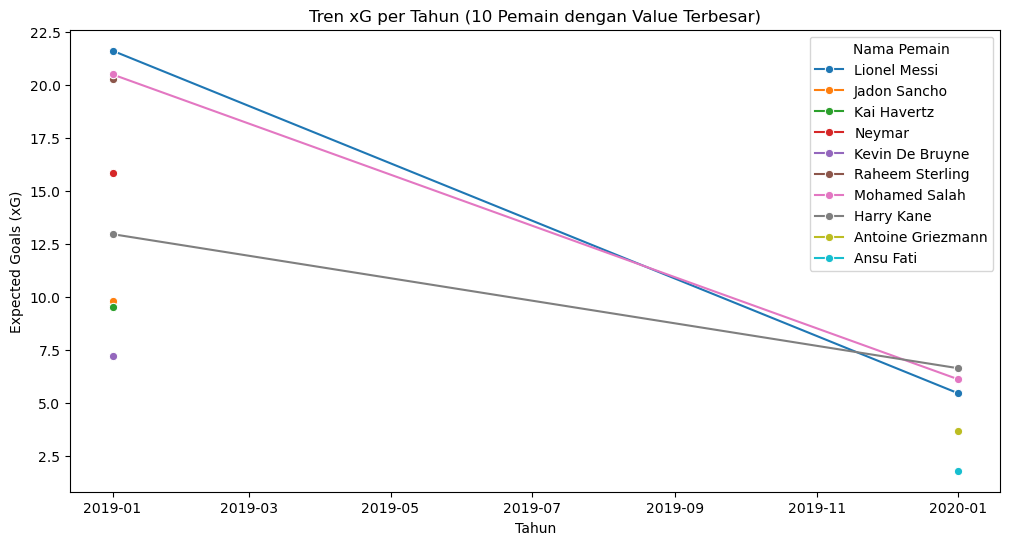

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERENDAH


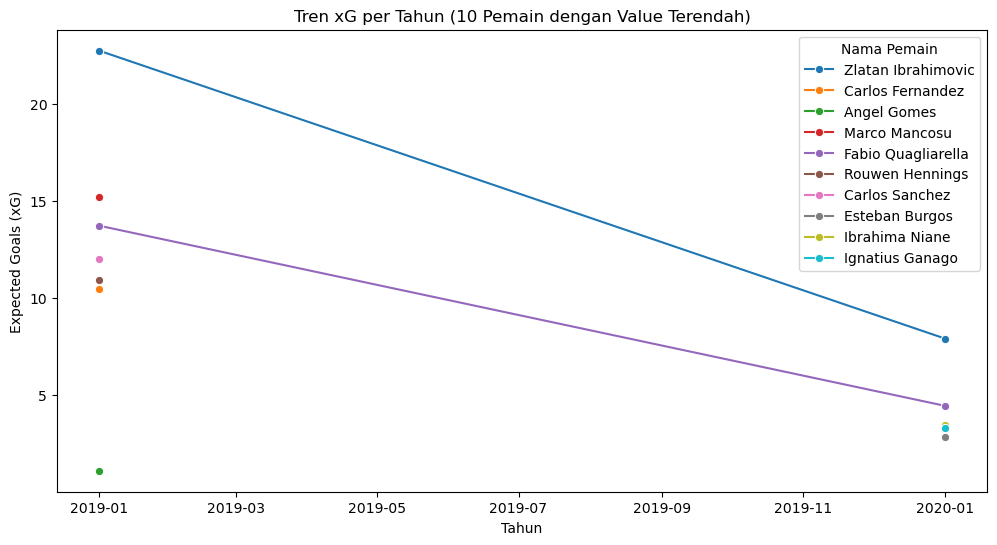

In [52]:
# Line Chart
def make_visuals(data, label):
    print(f"VISUALISASI UNTUK {label.upper()}")
    plt.figure(figsize=(12,6))
    sns.lineplot(data=data, x='Year', y='xG', hue='Nama Pemain', marker='o')
    plt.title(f'Tren xG per Tahun ({label})')
    plt.xlabel('Tahun')
    plt.ylabel('Expected Goals (xG)')
    plt.legend(title='Nama Pemain', bbox_to_anchor=(1,1))
    plt.show()
make_visuals(top10_df, "10 Pemain dengan Value Terbesar")
make_visuals(bottom10_df, "10 Pemain dengan Value Terendah")

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERBESAR


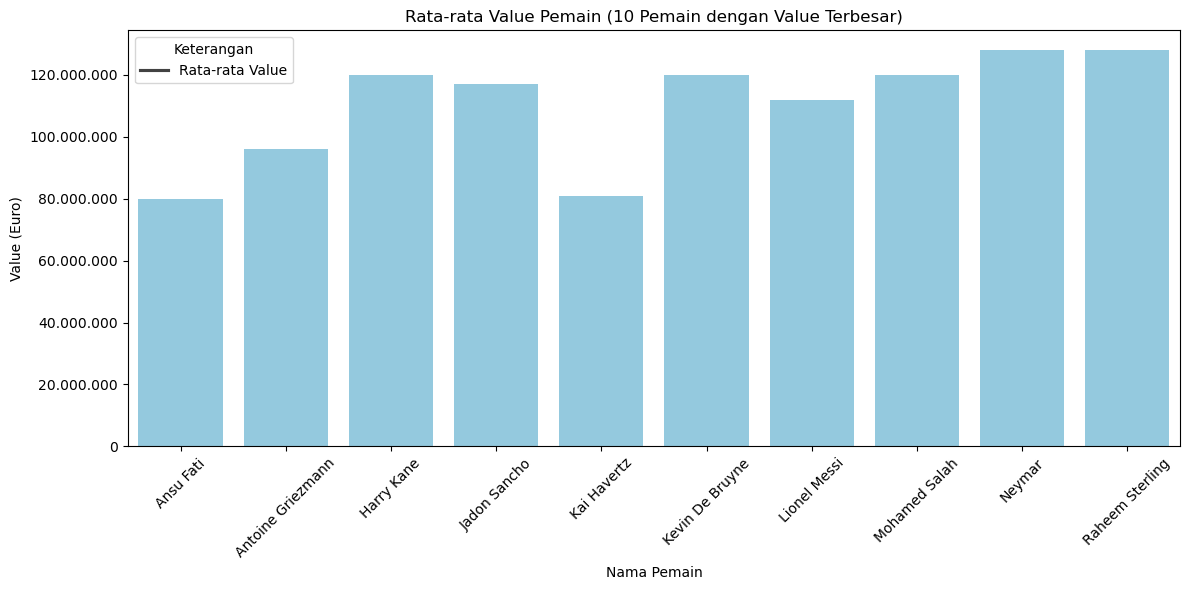

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERENDAH


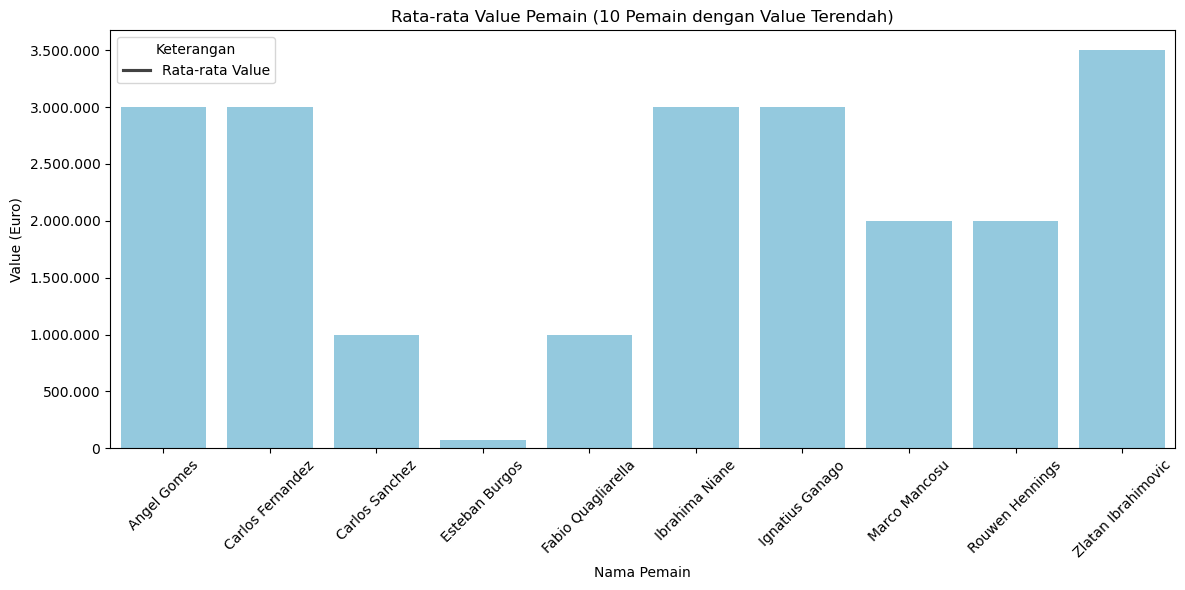

In [53]:
# Bar Chart
def make_visuals(data, label):
    print(f"VISUALISASI UNTUK {label.upper()}")
    avg_value = data.groupby('Nama Pemain')['value'].mean().reset_index()
    plt.figure(figsize=(12, 6))
    sns.barplot(data=avg_value, x='Nama Pemain', y='value', color='skyblue')

    plt.title(f'Rata-rata Value Pemain ({label})')
    plt.xlabel('Nama Pemain')
    plt.ylabel('Value (Euro)')
    plt.xticks(rotation=45)
    plt.legend(['Rata-rata Value'], title='Keterangan')

    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.'))
    )
    plt.tight_layout()
    plt.show()
make_visuals(top10_df, "10 Pemain dengan Value Terbesar")
make_visuals(bottom10_df, "10 Pemain dengan Value Terendah")

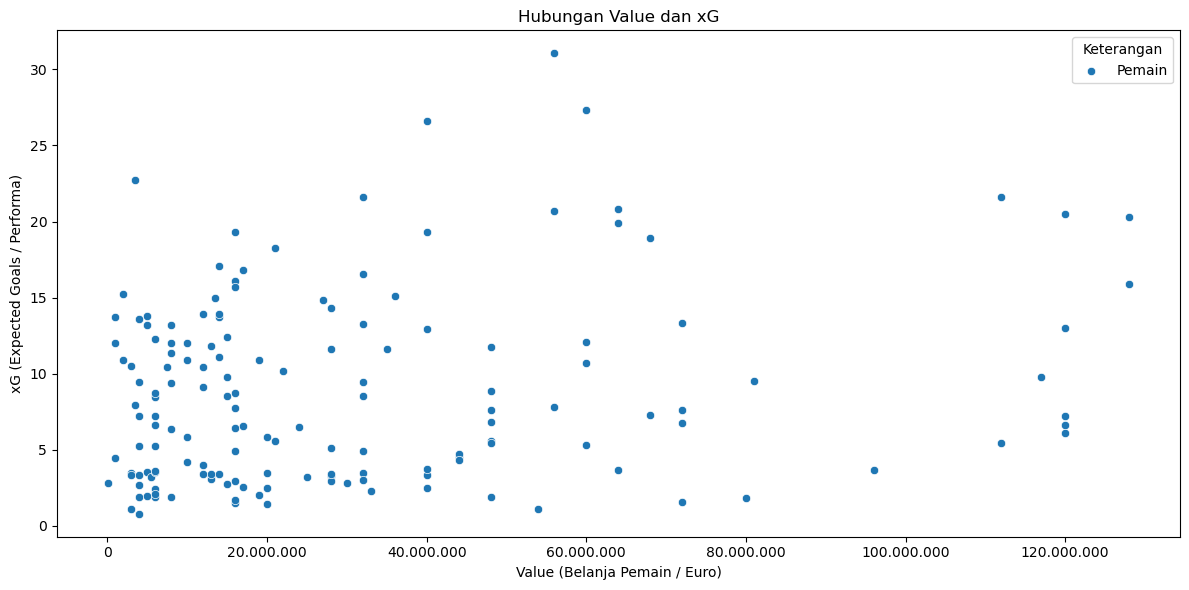

In [54]:
# Scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='value', y='xG')
plt.title('Hubungan Value dan xG')
plt.xlabel('Value (Belanja Pemain / Euro)')
plt.ylabel('xG (Expected Goals / Performa)')
plt.legend(['Pemain'], title='Keterangan')

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.'))
)
plt.tight_layout()
plt.show()

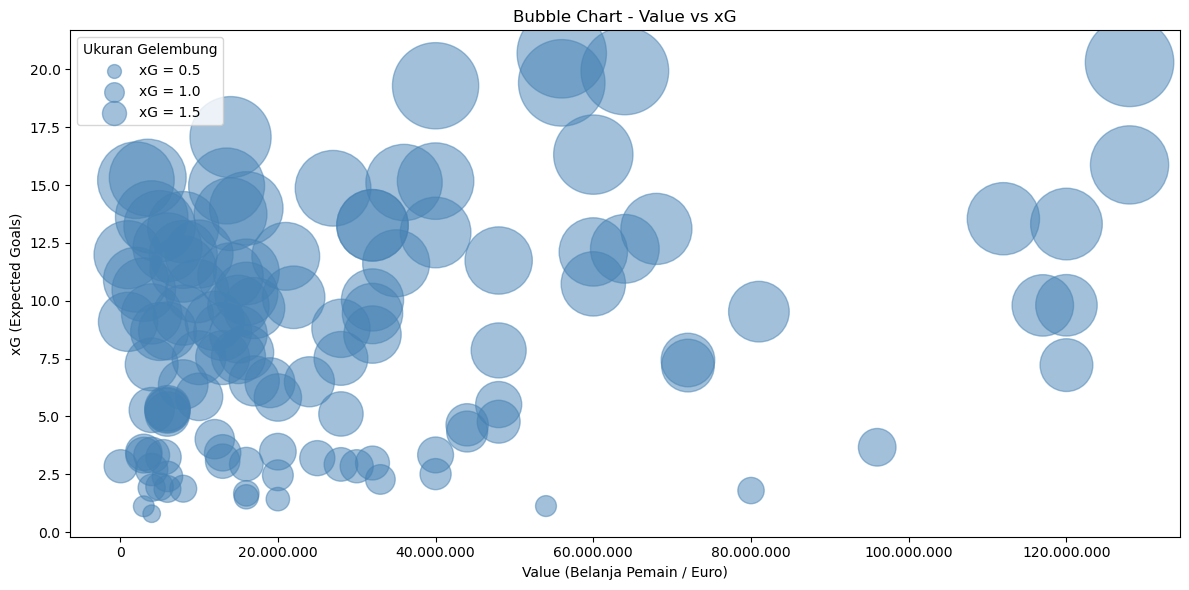

In [55]:
# Bubbe chart
bubble = df.groupby('Nama Pemain')[['value','xG']].mean().reset_index()

plt.figure(figsize=(12,6))
plt.scatter(bubble['value'], bubble['xG'], s=bubble['xG']*200, alpha=0.5, color='steelblue')

plt.title('Bubble Chart - Value vs xG')
plt.xlabel('Value (Belanja Pemain / Euro)')
plt.ylabel('xG (Expected Goals)')
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.'))
)
for size in [0.5, 1.0, 1.5]:
    plt.scatter([], [], s=size*200, label=f'xG = {size}', alpha=0.5, color='steelblue')
plt.legend(title='Ukuran Gelembung')

plt.tight_layout()
plt.show()

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERBESAR


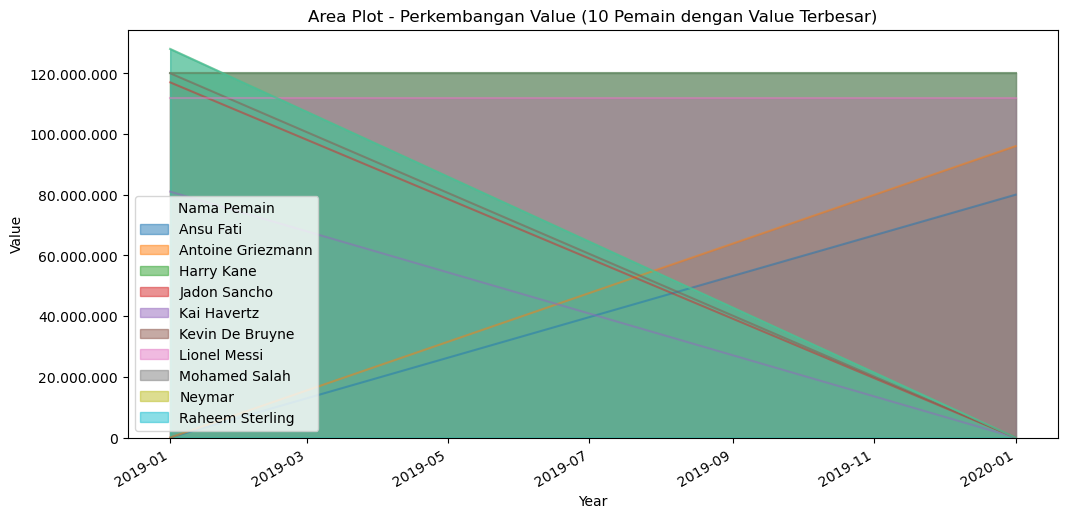

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERENDAH


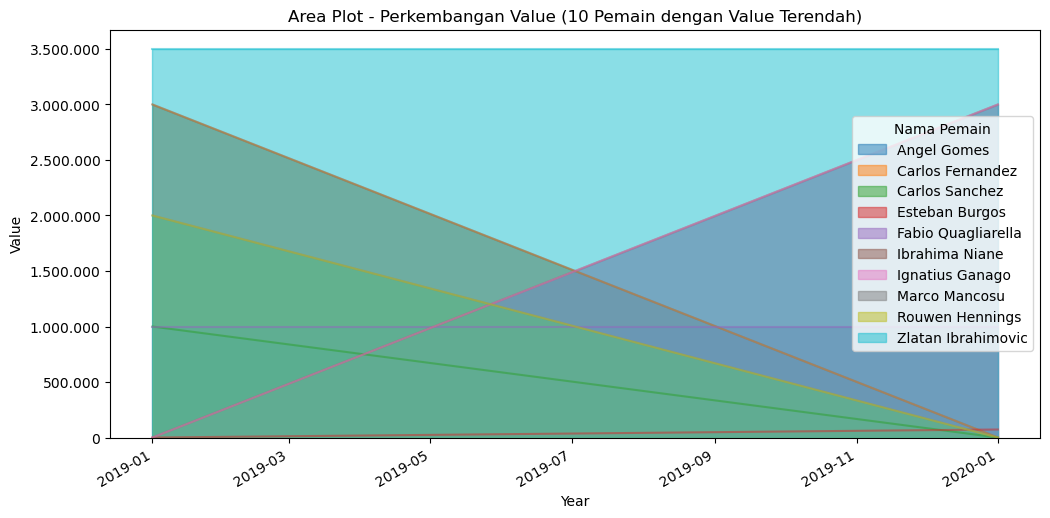

In [56]:
# Area plot
def make_visuals(data, label):
    print(f"VISUALISASI UNTUK {label.upper()}")
    pivot_value = data.pivot_table(index='Year', columns='Nama Pemain', values='value', aggfunc='mean')
    pivot_value.plot(kind='area', stacked=False, figsize=(12,6))
    plt.title(f'Area Plot - Perkembangan Value ({label})')
    plt.ylabel('Value')
    plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
    plt.show()
make_visuals(top10_df, "10 Pemain dengan Value Terbesar")
make_visuals(bottom10_df, "10 Pemain dengan Value Terendah")

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERBESAR


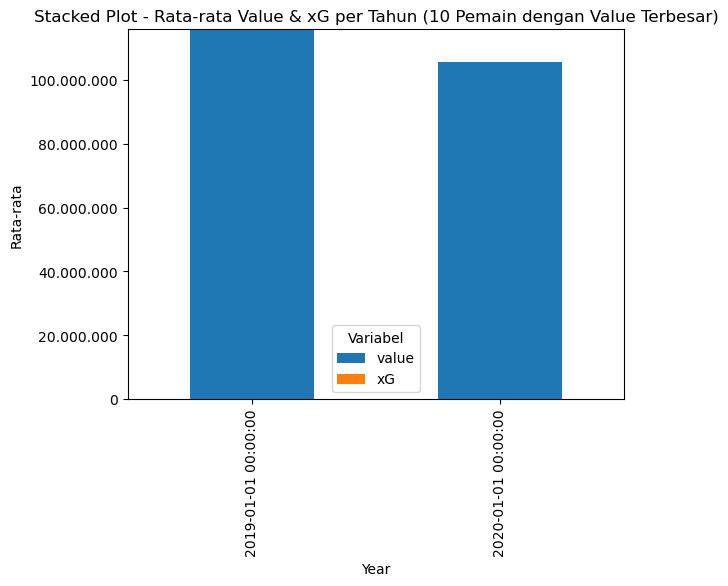

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERENDAH


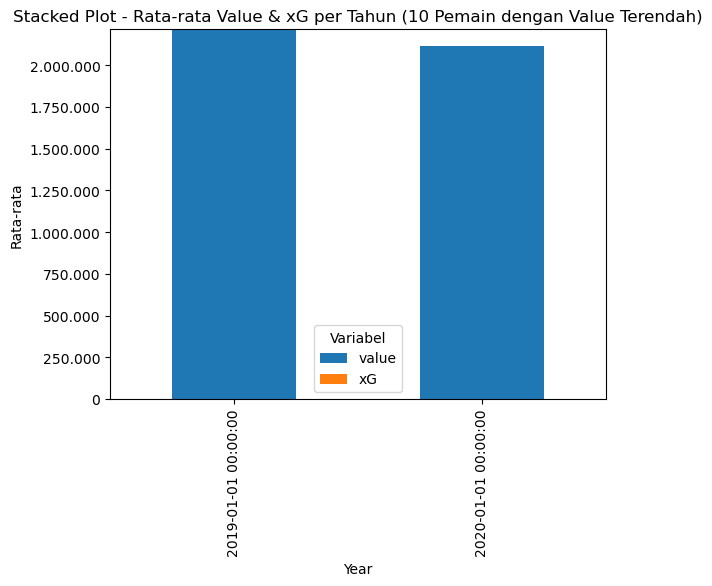

In [57]:
# Stacked plot
def make_visuals(data, label):
    print(f"VISUALISASI UNTUK {label.upper()}")
    pivot_stack = data.pivot_table(index='Year', values=['value','xG'], aggfunc='mean')
    pivot_stack.plot(kind='bar', stacked=True)
    plt.title(f'Stacked Plot - Rata-rata Value & xG per Tahun ({label})')
    plt.ylabel('Rata-rata')
    plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
    plt.show()
make_visuals(top10_df, "10 Pemain dengan Value Terbesar")
make_visuals(bottom10_df, "10 Pemain dengan Value Terendah")

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERBESAR


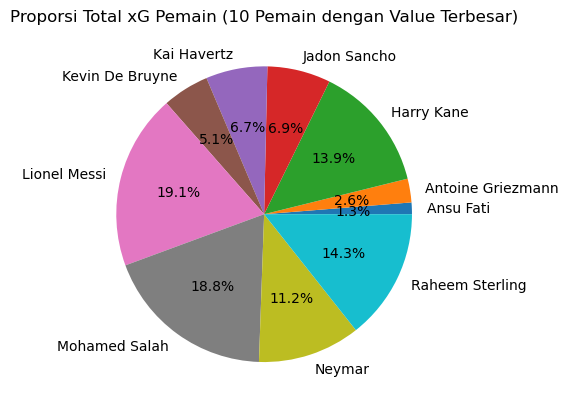

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERENDAH


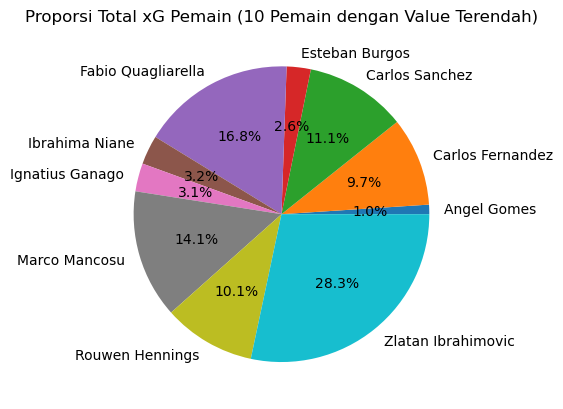

In [58]:
# Pie chart
def make_visuals(data, label):
    print(f"VISUALISASI UNTUK {label.upper()}")
    xg_sum = data.groupby('Nama Pemain')['xG'].sum()
    plt.pie(xg_sum, labels=xg_sum.index, autopct='%1.1f%%')
    plt.title(f'Proporsi Total xG Pemain ({label})')
    plt.show()
make_visuals(top10_df, "10 Pemain dengan Value Terbesar")
make_visuals(bottom10_df, "10 Pemain dengan Value Terendah")

In [59]:
# Tabel (Render Rapi)
def make_visuals(data, label):
    summary = data.groupby('Nama Pemain')[['value','xG']].mean().round(2).reset_index()
    print(f"Rangkuman Rata-rata Value dan xG ({label})")
    display(summary.style.set_table_styles(
        [{'selector': 'th', 'props': [('background-color', '#f2f2f2'), ('color', 'black'), ('text-align', 'center')]},
         {'selector': 'td', 'props': [('text-align', 'center')]}]
    ).set_caption(f"Tabel Rangkuman {label}"))
make_visuals(top10_df, "10 Pemain dengan Value Terbesar")
make_visuals(bottom10_df, "10 Pemain dengan Value Terendah")

Rangkuman Rata-rata Value dan xG (10 Pemain dengan Value Terbesar)


Variabel,Nama Pemain,value,xG
0,Ansu Fati,80000000.000000,1.800000
1,Antoine Griezmann,96000000.000000,3.670000
2,Harry Kane,120000000.000000,9.800000
3,Jadon Sancho,117000000.000000,9.800000
4,Kai Havertz,81000000.000000,9.530000
5,Kevin De Bruyne,120000000.000000,7.220000
6,Lionel Messi,112000000.000000,13.540000
7,Mohamed Salah,120000000.000000,13.320000
8,Neymar,128000000.000000,15.870000
9,Raheem Sterling,128000000.000000,20.300000


Rangkuman Rata-rata Value dan xG (10 Pemain dengan Value Terendah)


Variabel,Nama Pemain,value,xG
0,Angel Gomes,3000000.000000,1.120000
1,Carlos Fernandez,3000000.000000,10.480000
2,Carlos Sanchez,1000000.000000,11.990000
3,Esteban Burgos,72500.000000,2.850000
4,Fabio Quagliarella,1000000.000000,9.090000
5,Ibrahima Niane,3000000.000000,3.450000
6,Ignatius Ganago,3000000.000000,3.330000
7,Marco Mancosu,2000000.000000,15.210000
8,Rouwen Hennings,2000000.000000,10.910000
9,Zlatan Ibrahimovic,3500000.000000,15.320000


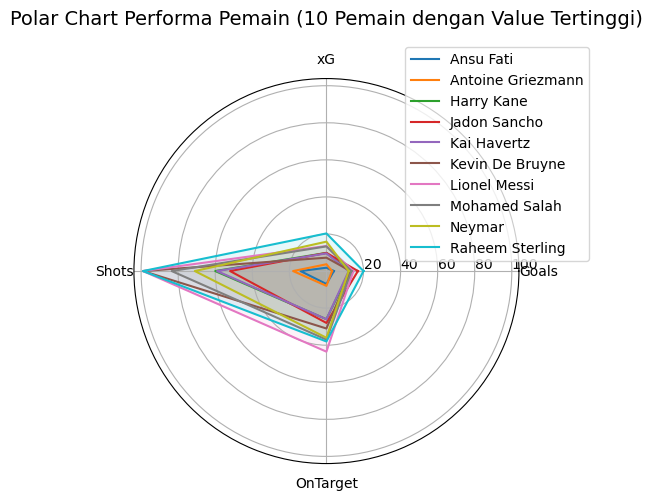

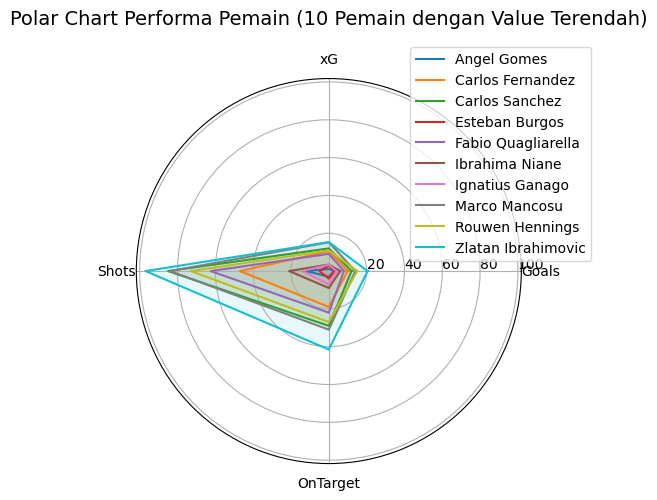

In [60]:
# Polar Chart
def polar_chart(data, label):
    # Pilih beberapa metrik performa
    metrics = ['Goals', 'xG', 'Shots', 'OnTarget']
    avg_data = data.groupby('Nama Pemain')[metrics].mean()
    top10 = avg_data.head(10)

    # Hitung sudut (angle) untuk setiap variabel
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(5, 5))
    ax = plt.subplot(111, polar=True)

    for idx, (player, row) in enumerate(top10.iterrows()):
        values = row.tolist()
        values += values[:1]
        ax.plot(angles, values, label=player)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)
    ax.set_rlabel_position(0)
    plt.title(f'Polar Chart Performa Pemain ({label})', size=14, pad=20)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
    plt.show()
polar_chart(top10_df, "10 Pemain dengan Value Tertinggi")
polar_chart(bottom10_df, "10 Pemain dengan Value Terendah")

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERBESAR


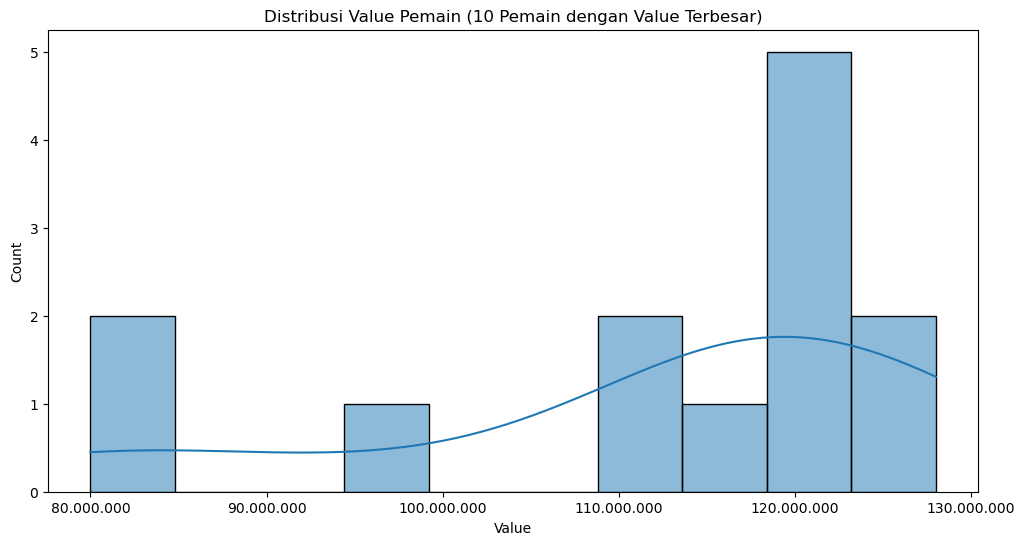

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERENDAH


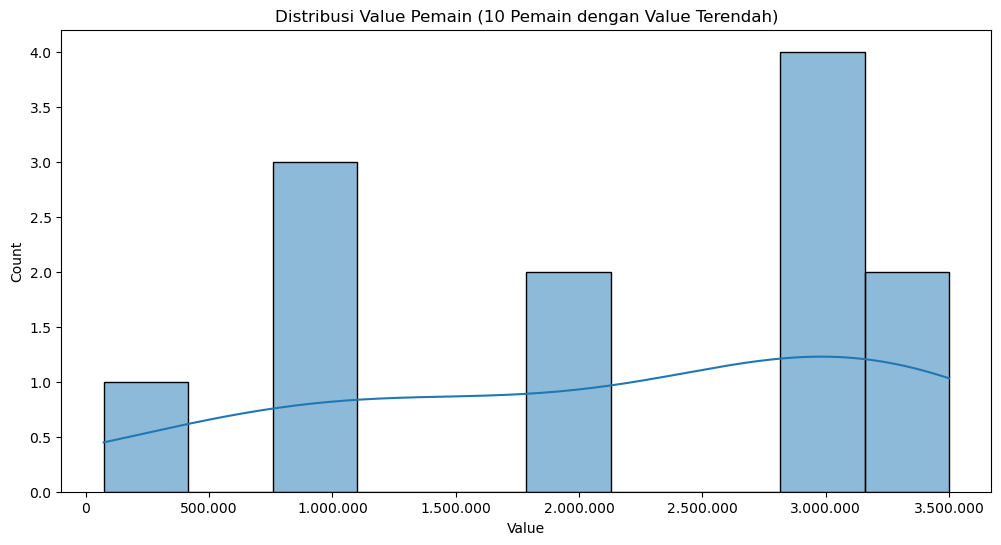

In [61]:
# Histogram
def make_visuals(data, label):
    print(f"VISUALISASI UNTUK {label.upper()}")
    plt.figure(figsize=(12,6))
    sns.histplot(data['value'], bins=10, kde=True)
    plt.title(f'Distribusi Value Pemain ({label})')
    plt.xlabel('Value')
    plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
    plt.show()
make_visuals(top10_df, "10 Pemain dengan Value Terbesar")
make_visuals(bottom10_df, "10 Pemain dengan Value Terendah")

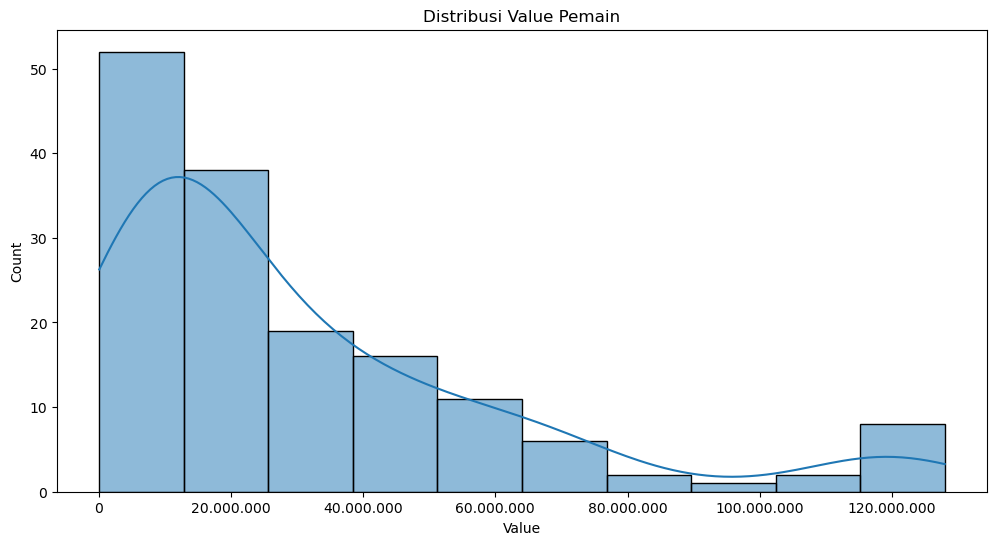

In [62]:
# Histogram
plt.figure(figsize=(12,6))
sns.histplot(df['value'], bins=10, kde=True)
plt.title('Distribusi Value Pemain')
plt.xlabel('Value')
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
plt.show()

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERBESAR


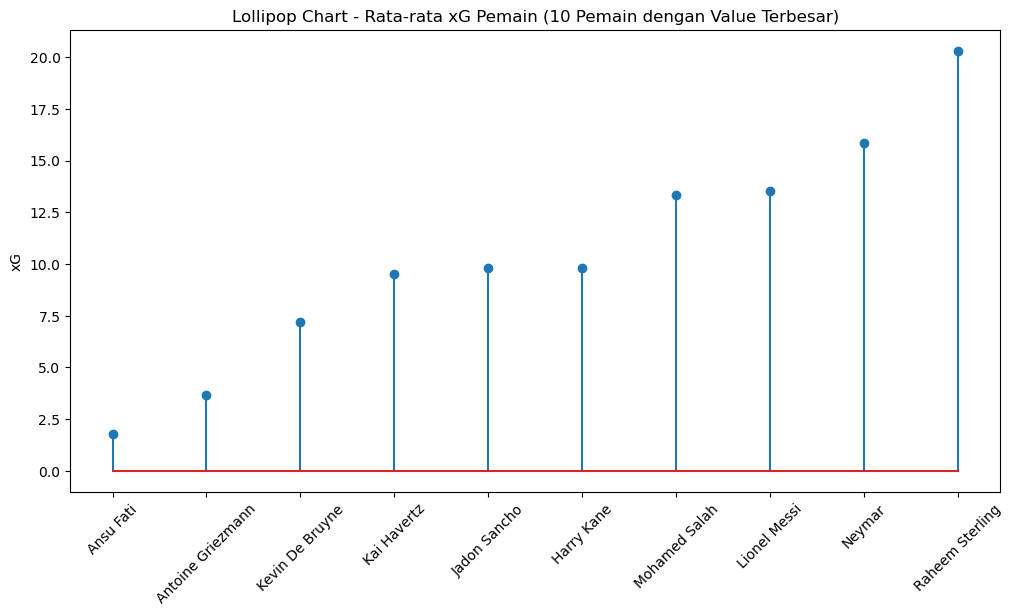

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERENDAH


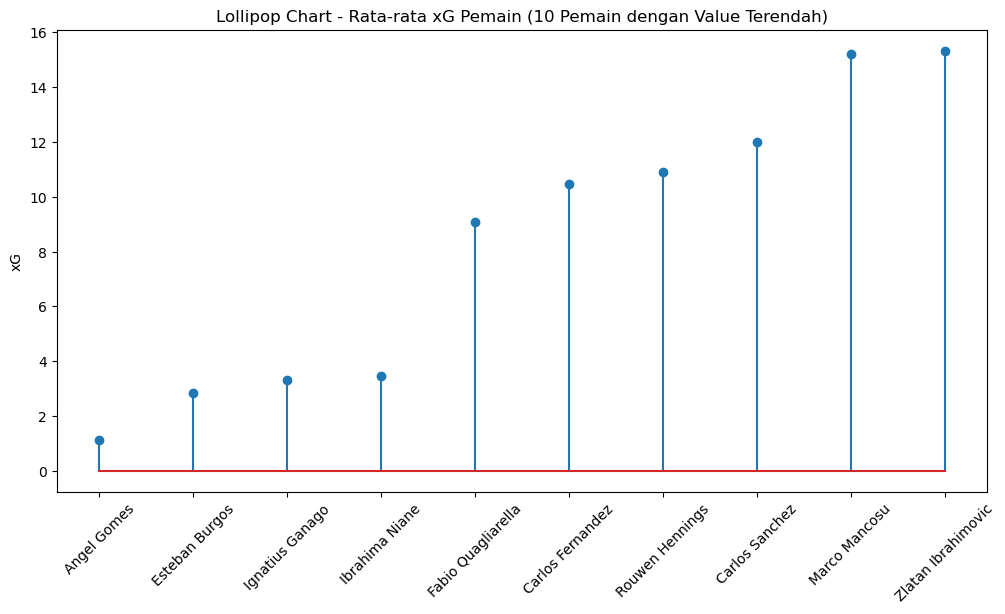

In [63]:
# Lollipop
def make_visuals(data, label):
    print(f"VISUALISASI UNTUK {label.upper()}")
    plt.figure(figsize=(12,6))
    mean_xg = data.groupby('Nama Pemain')['xG'].mean().sort_values()
    plt.stem(mean_xg.index, mean_xg.values)
    plt.title(f'Lollipop Chart - Rata-rata xG Pemain ({label})')
    plt.xticks(rotation=45)
    plt.ylabel('xG')
    plt.show()
make_visuals(top10_df, "10 Pemain dengan Value Terbesar")
make_visuals(bottom10_df, "10 Pemain dengan Value Terendah")

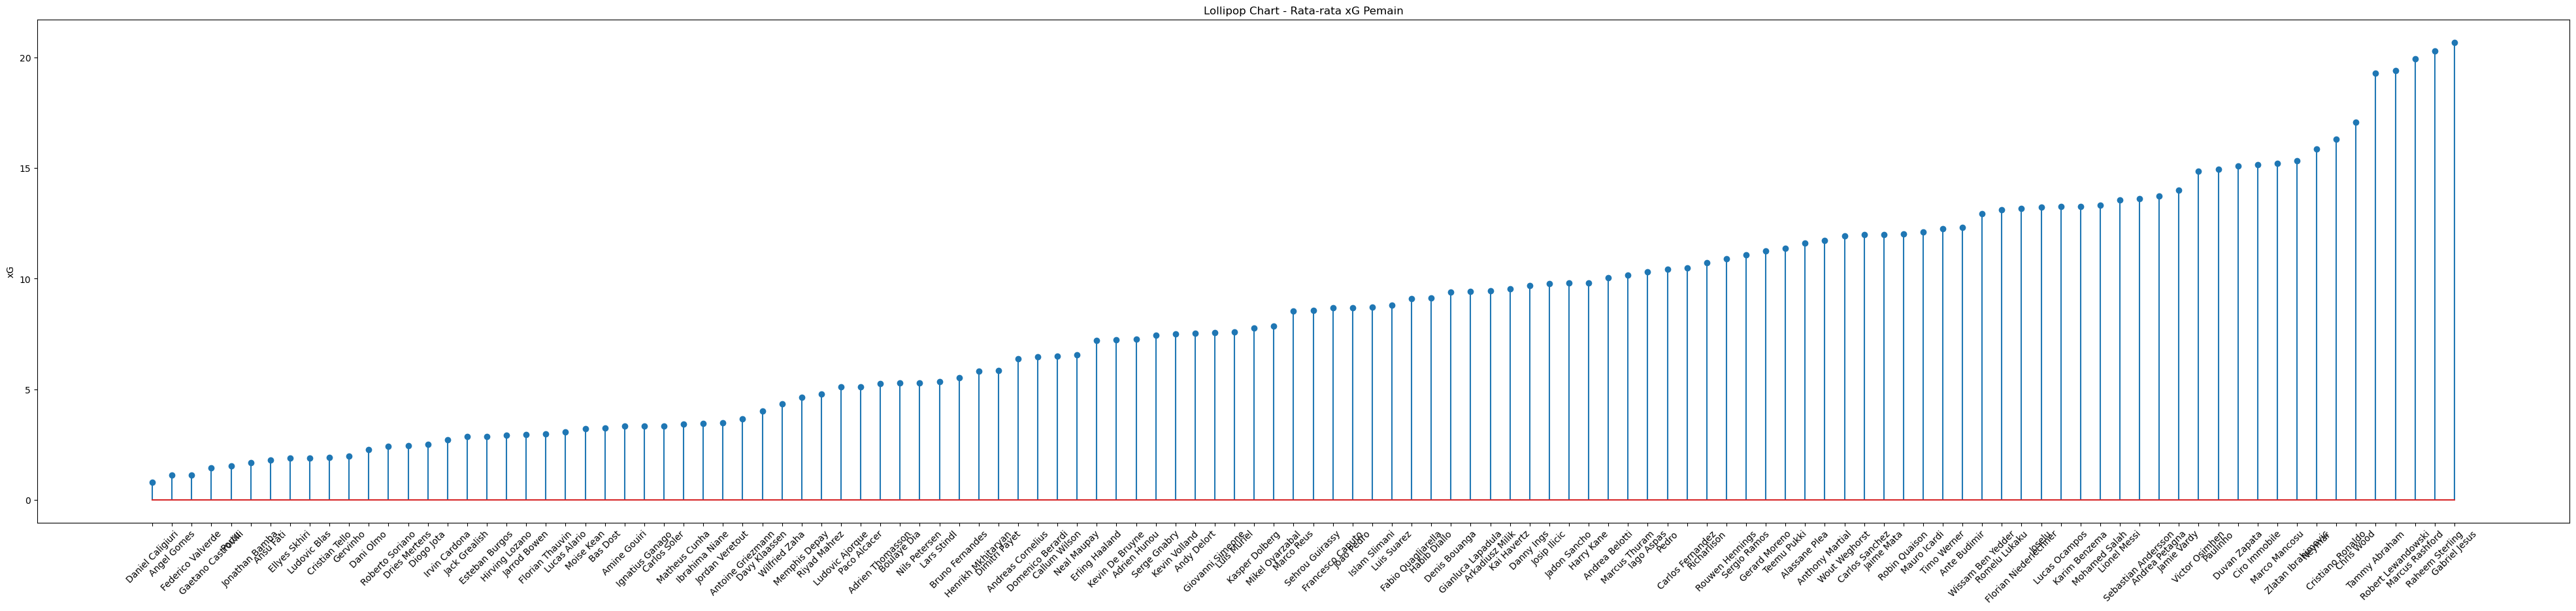

In [64]:
# Lollipop chart
plt.figure(figsize=(50,10))
mean_xg = df.groupby('Nama Pemain')['xG'].mean().sort_values()
plt.stem(mean_xg.index, mean_xg.values)
plt.title('Lollipop Chart - Rata-rata xG Pemain')
plt.xticks(rotation=45)
plt.ylabel('xG')
plt.show()

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERBESAR


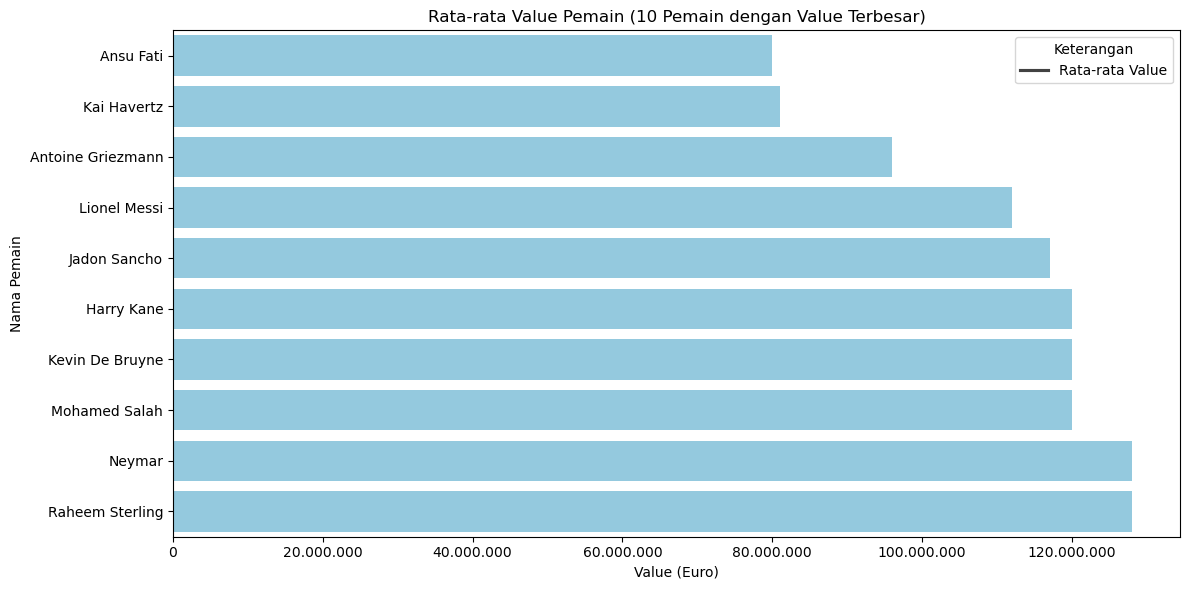

VISUALISASI UNTUK 10 PEMAIN DENGAN VALUE TERENDAH


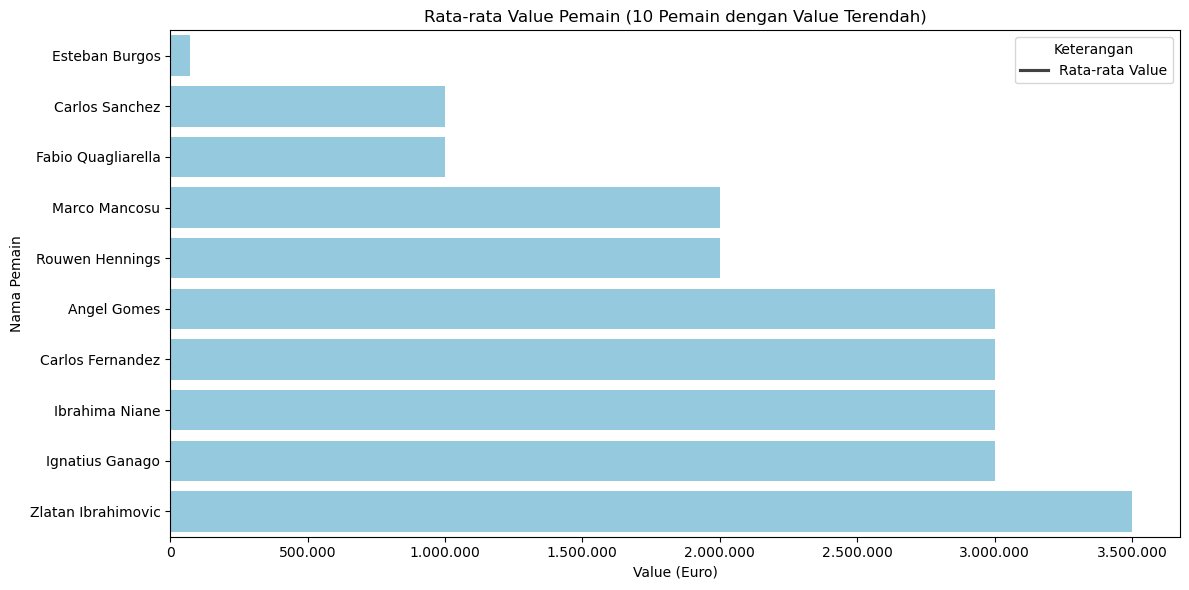


VISUALISASI 2: SCATTER PLOT (Hubungan Value dan Performa)


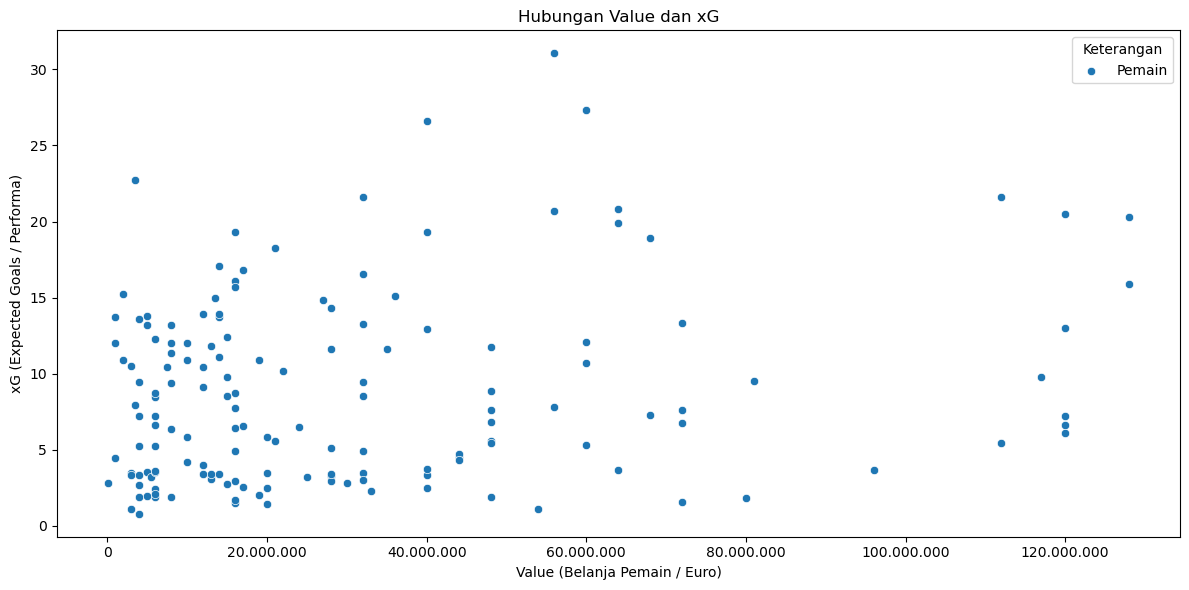


VISUALISASI 3: BUBBLE CHART (Value vs Performa dengan Ukuran Gelembung)


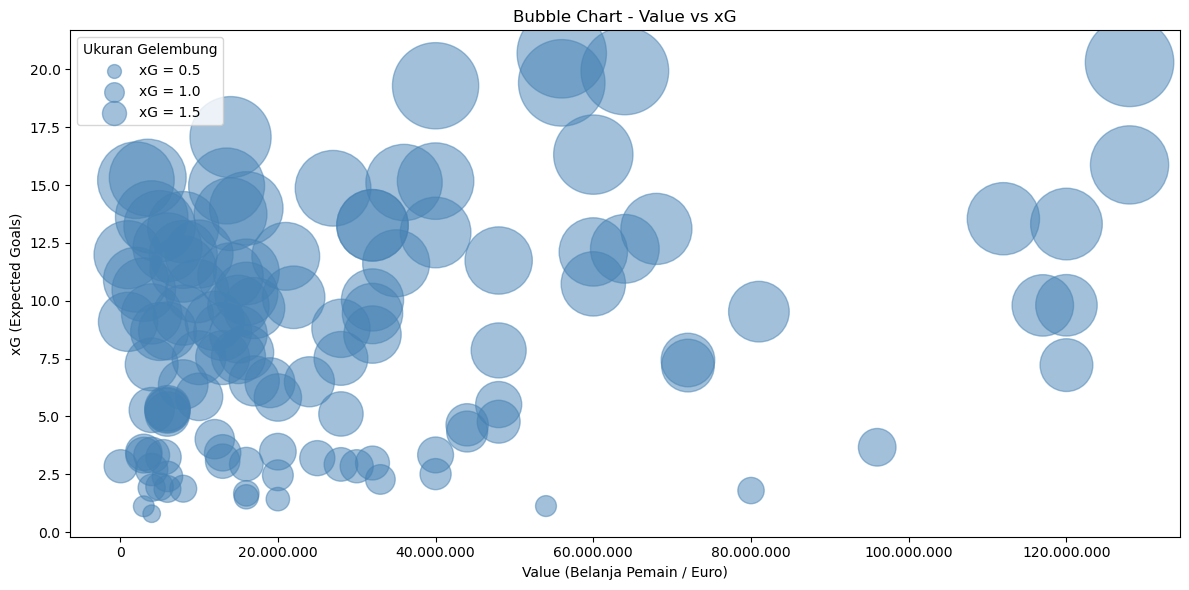

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. BAR CHART (Horizontal)
def make_visuals(data, label):
    print(f"VISUALISASI UNTUK {label.upper()}")
    avg_value = data.groupby('Nama Pemain')['value'].mean().reset_index()
    avg_value = avg_value.sort_values('value', ascending=True)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=avg_value, x='value', y='Nama Pemain', color='skyblue')
    plt.title(f'Rata-rata Value Pemain ({label})')
    plt.xlabel('Value (Euro)')
    plt.ylabel('Nama Pemain')
    plt.legend(['Rata-rata Value'], title='Keterangan')
    plt.gca().xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
    plt.tight_layout()
    plt.show()

# 2. SCATTER PLOT
def scatter_plot(df):
    print("\nVISUALISASI 2: SCATTER PLOT (Hubungan Value dan Performa)")
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=df, x='value', y='xG')
    plt.title('Hubungan Value dan xG')
    plt.xlabel('Value (Belanja Pemain / Euro)')
    plt.ylabel('xG (Expected Goals / Performa)')
    plt.legend(['Pemain'], title='Keterangan')
    plt.gca().xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
    plt.tight_layout()
    plt.show()

# 3. BUBBLE CHART
def bubble_chart(df):
    print("\nVISUALISASI 3: BUBBLE CHART (Value vs Performa dengan Ukuran Gelembung)")
    bubble = df.groupby('Nama Pemain')[['value','xG']].mean().reset_index()

    plt.figure(figsize=(12,6))
    plt.scatter(bubble['value'], bubble['xG'], s=bubble['xG']*200, alpha=0.5, color='steelblue')
    plt.title('Bubble Chart - Value vs xG')
    plt.xlabel('Value (Belanja Pemain / Euro)')
    plt.ylabel('xG (Expected Goals)')
    plt.gca().xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
    for size in [0.5, 1.0, 1.5]:
      plt.scatter([], [], s=size*200, label=f'xG = {size}', alpha=0.5, color='steelblue')
      plt.legend(title='Ukuran Gelembung')
    plt.tight_layout()
    plt.show()

make_visuals(top10_df, "10 Pemain dengan Value Terbesar")
make_visuals(bottom10_df, "10 Pemain dengan Value Terendah")
scatter_plot(df)
bubble_chart(df)

## Stats Analyst

### Statistika Deskriptif

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 155 entries, Pemain1 to Pemain155
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Negara                   155 non-null    object        
 1   Liga                     155 non-null    object        
 2   Klub                     155 non-null    object        
 3   Nama Pemain              155 non-null    object        
 4   Pertandingan             155 non-null    int64         
 5   Pergantian               155 non-null    int64         
 6   Menit                    155 non-null    int64         
 7   Goals                    155 non-null    int64         
 8   xG                       155 non-null    float64       
 9   xG Per Avg Match         155 non-null    float64       
 10  Shots                    155 non-null    int64         
 11  OnTarget                 155 non-null    int64         
 12  Shots Per Avg Match      155 

In [67]:
# Pisahkan berdasarkan tipe
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print("Kolom numerik:", list(num_cols))
print("Kolom kategorikal:", list(cat_cols))

Kolom numerik: ['Pertandingan', 'Pergantian', 'Menit', 'Goals', 'xG', 'xG Per Avg Match', 'Shots', 'OnTarget', 'Shots Per Avg Match', 'On Target Per Avg Match', 'value']
Kolom kategorikal: ['Negara', 'Liga', 'Klub', 'Nama Pemain', 'Belanja_Bin', 'xG_Bin', 'Segmentasi_Pemain']


In [68]:
print("\nStatistik Deskriptif untuk Kolom Numerik:")
df[num_cols].describe()


Statistik Deskriptif untuk Kolom Numerik:


Variabel,Pertandingan,Pergantian,Menit,Goals,xG,xG Per Avg Match,Shots,OnTarget,Shots Per Avg Match,On Target Per Avg Match,value
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,1.550000e+02
mean,17.709677,2.187097,1642.896774,10.154839,8.739742,0.521742,52.019355,22.741935,3.004581,1.344839,3.075853e+07
std,10.715305,3.220847,1002.809172,6.553617,6.163439,0.226223,37.457417,15.964180,1.054845,0.492347,3.132213e+07
min,3.000000,0.000000,264.000000,3.000000,0.800000,0.090000,5.000000,3.000000,0.800000,0.400000,7.250000e+04
25%,8.000000,0.000000,738.500000,5.000000,3.440000,0.380000,21.000000,9.000000,2.270000,1.015000,8.000000e+06
50%,12.000000,1.000000,1325.000000,9.000000,7.250000,0.460000,39.000000,19.000000,2.940000,1.270000,1.700000e+07
75%,28.500000,3.000000,2621.500000,13.000000,12.355000,0.645000,80.500000,35.000000,3.455000,1.620000,4.400000e+07
max,37.000000,23.000000,3474.000000,36.000000,31.050000,1.350000,208.000000,79.000000,7.200000,3.110000,1.280000e+08


In [69]:
print("\nStatistik Deskriptif untuk Kolom Kategorikal:")
df[cat_cols].describe()


Statistik Deskriptif untuk Kolom Kategorikal:


Variabel,Negara,Liga,Klub,Nama Pemain,Belanja_Bin,xG_Bin,Segmentasi_Pemain
count,155,155,155,155,155,155,155
unique,9,27,78,118,4,4,16
top,Italy,Serie A,(CAG),Joao Pedro,Murah,Rendah,Murah - Rendah
freq,37,37,6,4,43,39,13


In [70]:
import pandas as pd
import numpy as np

# Pilih kolom numerik
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Buat DataFrame penyebaran
spread_df = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Mode': [df[col].mode()[0] if not df[col].mode().empty else np.nan for col in num_cols],
    'Variance': df[num_cols].var(),
    'Std_Dev': df[num_cols].std(),
    'IQR': df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25),
    'Range': df[num_cols].max() - df[num_cols].min(),})

# Tampilkan hasil
print("📊 Ukuran Pemusatan & Penyebaran Data Numerik:")
display(spread_df)

📊 Ukuran Pemusatan & Penyebaran Data Numerik:


,Mean,Median,Mode,Variance,Std_Dev,IQR,Range
Variabel,,,,,,,
Pertandingan,1.770968e+01,12.00,9.00,1.148178e+02,1.071531e+01,2.050000e+01,3.400000e+01
Pergantian,2.187097e+00,1.00,0.00,1.037386e+01,3.220847e+00,3.000000e+00,2.300000e+01
Menit,1.642897e+03,1325.00,831.00,1.005626e+06,1.002809e+03,1.883000e+03,3.210000e+03
Goals,1.015484e+01,9.00,4.00,4.294990e+01,6.553617e+00,8.000000e+00,3.300000e+01
xG,8.739742e+00,7.25,2.85,3.798798e+01,6.163439e+00,8.915000e+00,3.025000e+01
xG Per Avg Match,5.217419e-01,0.46,0.39,5.117682e-02,2.262229e-01,2.650000e-01,1.260000e+00
Shots,5.201935e+01,39.00,21.00,1.403058e+03,3.745742e+01,5.950000e+01,2.030000e+02
OnTarget,2.274194e+01,19.00,8.00,2.548550e+02,1.596418e+01,2.600000e+01,7.600000e+01
Shots Per Avg Match,3.004581e+00,2.94,1.82,1.112698e+00,1.054845e+00,1.185000e+00,6.400000e+00


In [71]:
for col in cat_cols:
    print(f"\n=== Distribusi Nilai Kolom '{col}' ===")
    print(df[col].value_counts(normalize=True).head(10))


=== Distribusi Nilai Kolom 'Negara' ===
Negara
Italy           0.238710
Germany         0.187097
France          0.180645
England         0.174194
Spain           0.167742
Portugal        0.019355
Brazil          0.019355
USA             0.006452
 Netherlands    0.006452
Name: proportion, dtype: float64

=== Distribusi Nilai Kolom 'Liga' ===
Liga
Serie A                           0.238710
Bundesliga                        0.187097
Premier League                    0.174194
La Liga                           0.167742
Campeonato Brasileiro SÃ©rie A    0.019355
Primeira Liga                     0.019355
France Ligue 2                    0.012903
France Ligue 5                    0.012903
France Ligue 16                   0.012903
France Ligue 10                   0.012903
Name: proportion, dtype: float64

=== Distribusi Nilai Kolom 'Klub' ===
Klub
(CAG)    0.038710
(MNC)    0.032258
(ATA)    0.032258
(NAP)    0.032258
(STR)    0.025806
(CHE)    0.025806
(DOR)    0.025806
(BAY)    0.025806

In [72]:
# Menghitung Skewness dan Kurtosis tiap kolom numerik
skew_kurt = pd.DataFrame({
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurt()
})

# Menampilkan hasil dengan pembulatan
skew_kurt = skew_kurt.round(3)
display(skew_kurt)

,Skewness,Kurtosis
Variabel,,
Pertandingan,0.368,-1.504
Pergantian,2.944,12.410
Menit,0.341,-1.498
Goals,1.447,2.541
xG,1.006,0.736
xG Per Avg Match,1.071,1.501
Shots,1.084,1.293
OnTarget,1.086,1.024
Shots Per Avg Match,0.933,1.972


Skewness: Mengukur asimetris distribusi data terhadap mean

• = 0 → simetris (normal)

• > 0 → miring kanan (lebih banyak nilai kecil)

• < 0 → miring kiri (lebih banyak nilai besar)

Kurtosis: Mengukur keruncingan (seberapa tajam puncak distribusi)

• = 3 → normal (mesokurtic)

• > 3 → puncak tajam (leptokurtic, banyak nilai di sekitar mean)

• < 3 → puncak datar (platykurtic, data lebih tersebar)

### Distribusi Normal

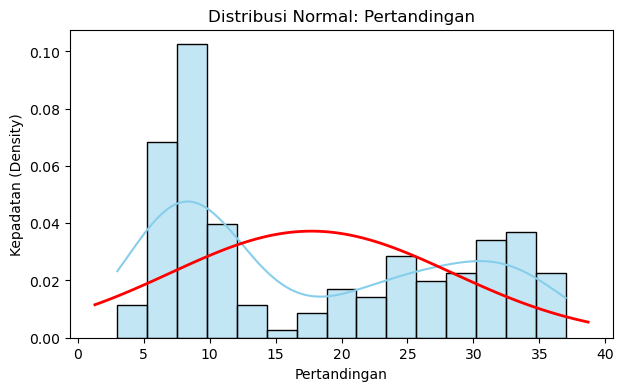

📊 Pertandingan
  Mean      : 17.71
  Median    : 12.00
  Std Dev   : 10.72
  Skewness  : 0.37
  Kurtosis  : -1.50
------------------------------------------------------------


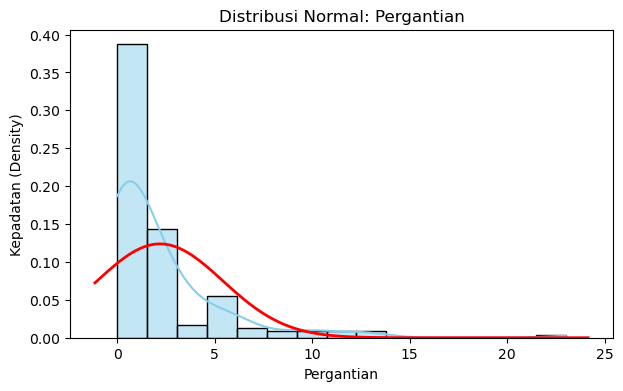

📊 Pergantian
  Mean      : 2.19
  Median    : 1.00
  Std Dev   : 3.22
  Skewness  : 2.94
  Kurtosis  : 12.41
------------------------------------------------------------


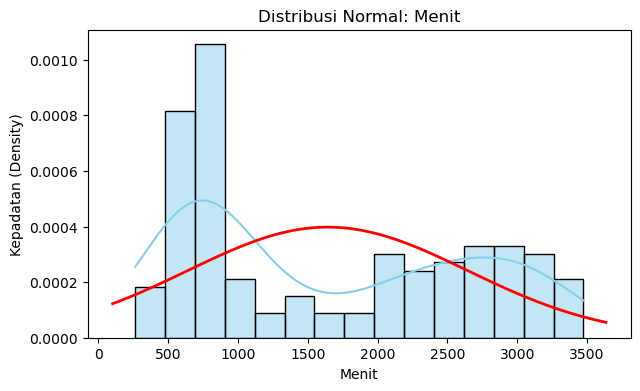

📊 Menit
  Mean      : 1642.90
  Median    : 1325.00
  Std Dev   : 1002.81
  Skewness  : 0.34
  Kurtosis  : -1.50
------------------------------------------------------------


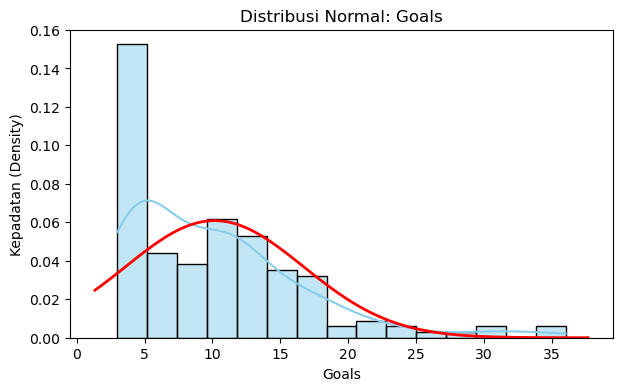

📊 Goals
  Mean      : 10.15
  Median    : 9.00
  Std Dev   : 6.55
  Skewness  : 1.45
  Kurtosis  : 2.54
------------------------------------------------------------


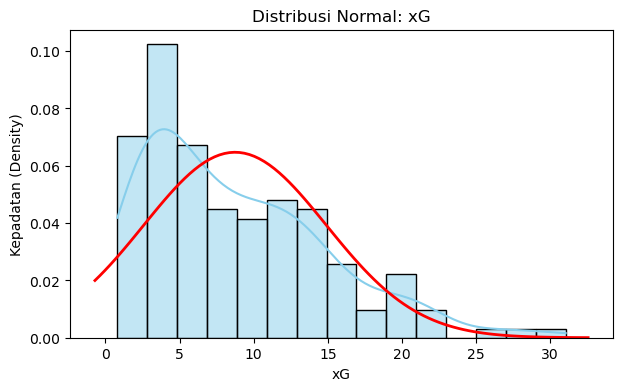

📊 xG
  Mean      : 8.74
  Median    : 7.25
  Std Dev   : 6.16
  Skewness  : 1.01
  Kurtosis  : 0.74
------------------------------------------------------------


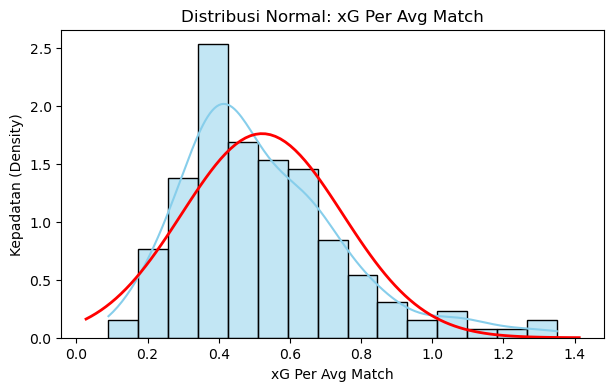

📊 xG Per Avg Match
  Mean      : 0.52
  Median    : 0.46
  Std Dev   : 0.23
  Skewness  : 1.07
  Kurtosis  : 1.50
------------------------------------------------------------


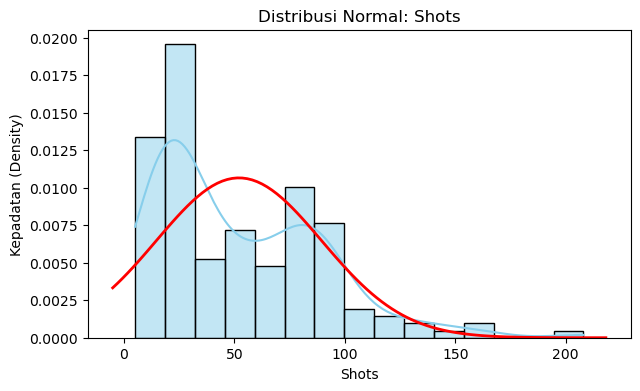

📊 Shots
  Mean      : 52.02
  Median    : 39.00
  Std Dev   : 37.46
  Skewness  : 1.08
  Kurtosis  : 1.29
------------------------------------------------------------


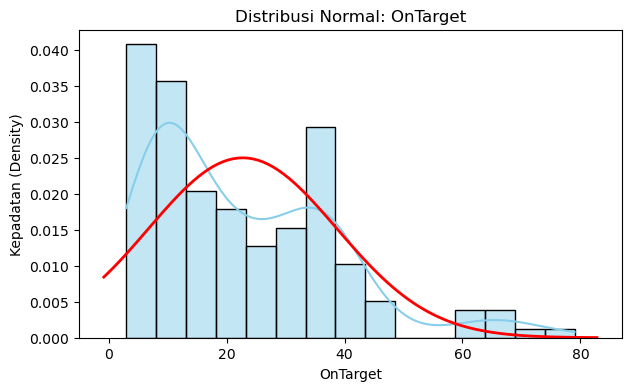

📊 OnTarget
  Mean      : 22.74
  Median    : 19.00
  Std Dev   : 15.96
  Skewness  : 1.09
  Kurtosis  : 1.02
------------------------------------------------------------


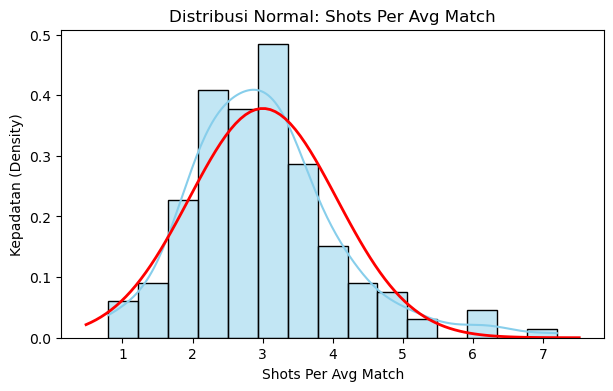

📊 Shots Per Avg Match
  Mean      : 3.00
  Median    : 2.94
  Std Dev   : 1.05
  Skewness  : 0.93
  Kurtosis  : 1.97
------------------------------------------------------------


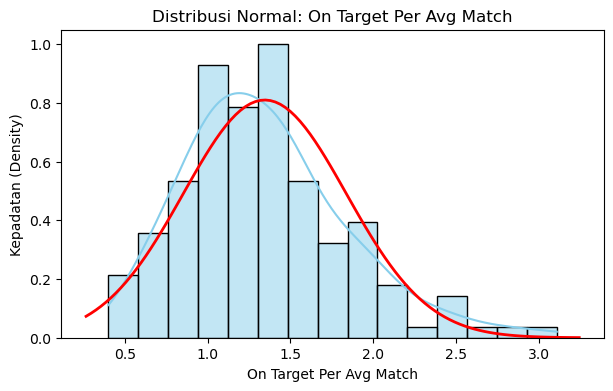

📊 On Target Per Avg Match
  Mean      : 1.34
  Median    : 1.27
  Std Dev   : 0.49
  Skewness  : 0.82
  Kurtosis  : 0.90
------------------------------------------------------------


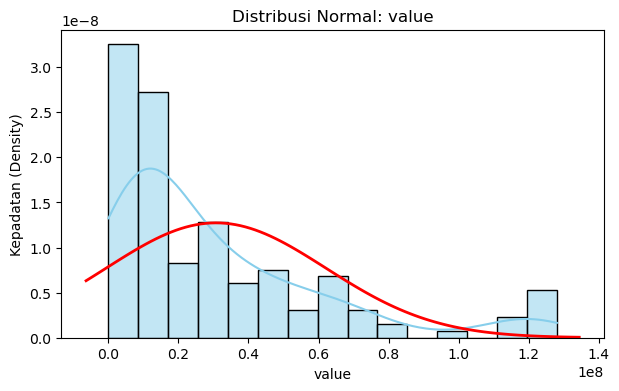

📊 value
  Mean      : 30758532.26
  Median    : 17000000.00
  Std Dev   : 31322134.69
  Skewness  : 1.58
  Kurtosis  : 1.97
------------------------------------------------------------


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Identifikasi column numerik
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot distribusi + kurva normal teoritis
for column in num_cols:
    plt.figure(figsize=(7,4))

    # Plot histogram dan KDE
    sns.histplot(df[column], kde=True, stat="density", color="skyblue", bins=15)

    # Kurva normal teoritis berdasarkan mean & std aktual
    mean = df[column].mean()
    std = df[column].std()
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mean, std)
    plt.plot(x, p, 'r', linewidth=2)

    # Judul dan label
    plt.title(f'Distribusi Normal: {column}', fontsize=12)
    plt.xlabel(column)
    plt.ylabel('Kepadatan (Density)')
    plt.show()

    # Cetak statistik utama
    print(f"📊 {column}")
    print(f"  Mean      : {mean:.2f}")
    print(f"  Median    : {df[column].median():.2f}")
    print(f"  Std Dev   : {std:.2f}")
    print(f"  Skewness  : {df[column].skew():.2f}")
    print(f"  Kurtosis  : {df[column].kurtosis():.2f}")
    print("-"*60)

Kapan Disebut Distribusi Normal

 **Mean ≈ Median** → Data simetris      
 **Skewness ≈ 0** → Tidak condong ke kiri/kanan     
 **Kurtosis ≈ 0** → Puncak data mirip normal        
 **Kurva merah & histogram biru tumpang tindih** → Bentuk mendekati normal     


### Distribusi Uniform

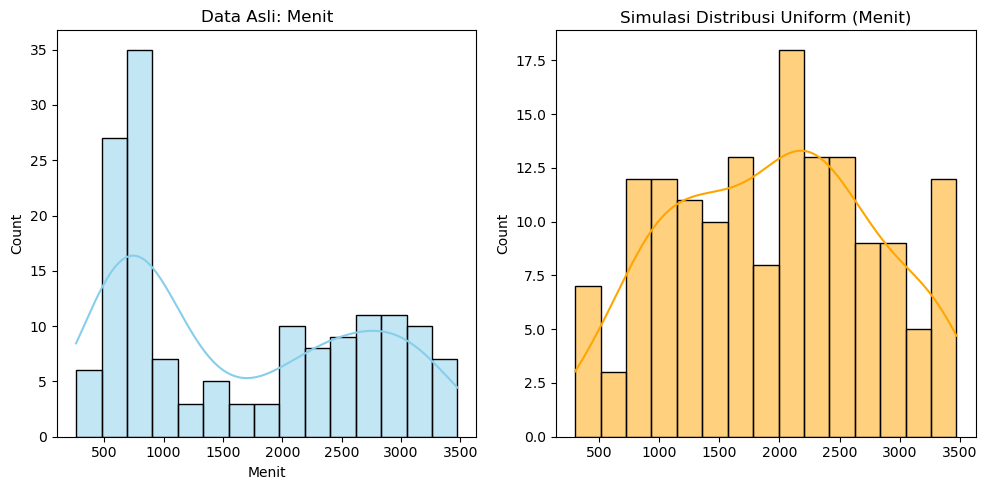

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Kolom contoh dari dataset kamu
kolom = 'Menit'

# Data asli dari kolom "Menit"
data_asli = df[kolom]

# Simulasi data uniform dalam rentang yang sama
uniform_data = np.random.uniform(low=data_asli.min(), high=data_asli.max(), size=len(data_asli))

# Plot perbandingan
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.histplot(data_asli, kde=True, color='skyblue', bins=15)
plt.title(f'Data Asli: {kolom}')

plt.subplot(1,2,2)
sns.histplot(uniform_data, kde=True, color='orange', bins=15)
plt.title(f'Simulasi Distribusi Uniform ({kolom})')

plt.tight_layout()
plt.show()

Kapan Disebut Distribusi Uniform
       
Semua nilai muncul dengan frekuensi hampir sama → Tidak ada nilai yang dominan      
Histogram datar tanpa puncak → Kepadatan data merata di seluruh rentang     
Skewness ≈ 0 → Tidak condong ke kiri atau kanan         
Kurtosis ≈ −1.2 → Bentuk distribusi lebih “rata” dari normal            
Setiap nilai dalam rentang memiliki peluang sama → Data benar-benar seragam         

### Distribusi Eksponensial

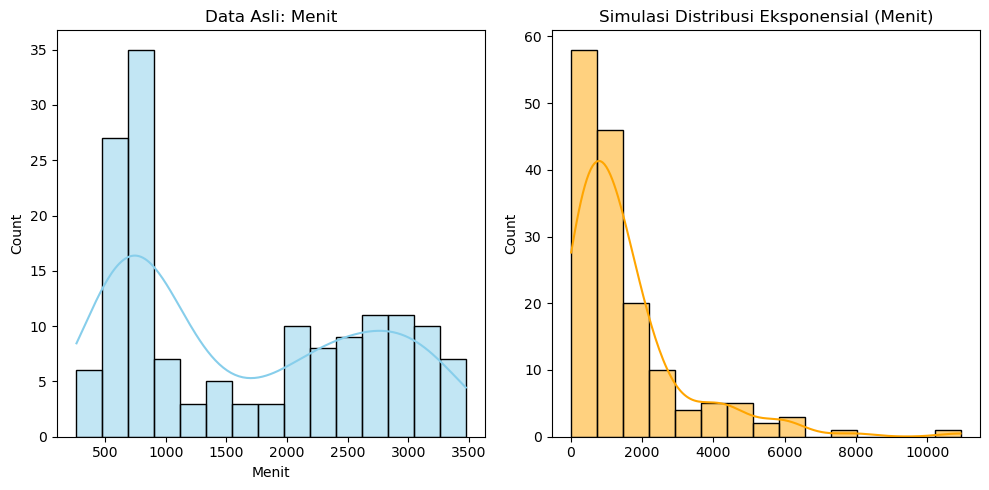

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import expon

kolom = 'Menit'

# Data asli
data_asli = df[kolom]

# Estimasi parameter lambda dari mean data
lambda_est = 1 / data_asli.mean()

# Simulasi distribusi eksponensial dengan parameter lambda yang sama
simulasi_expon = np.random.exponential(scale=1/lambda_est, size=len(data_asli))

# Plot perbandingan
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.histplot(data_asli, kde=True, color='skyblue', bins=15)
plt.title(f'Data Asli: {kolom}')

plt.subplot(1,2,2)
sns.histplot(simulasi_expon, kde=True, color='orange', bins=15)
plt.title(f'Simulasi Distribusi Eksponensial ({kolom})')

plt.tight_layout()
plt.show()

Kapan Disebut Distribusi Eksponensial

Nilai tidak negatif (≥ 0) → Representasi waktu atau jarak antar kejadian        
Histogram condong ke kanan (right-skewed) → Banyak nilai kecil, sedikit nilai besar         
Skewness > 0 → Data menurun dari kiri ke kanan      
Mean ≈ Std Dev → Ciri khas eksponensial         
Peluang menurun seiring waktu → Semakin lama, semakin kecil kemungkinan kejadian            

### Distribusi Binomial

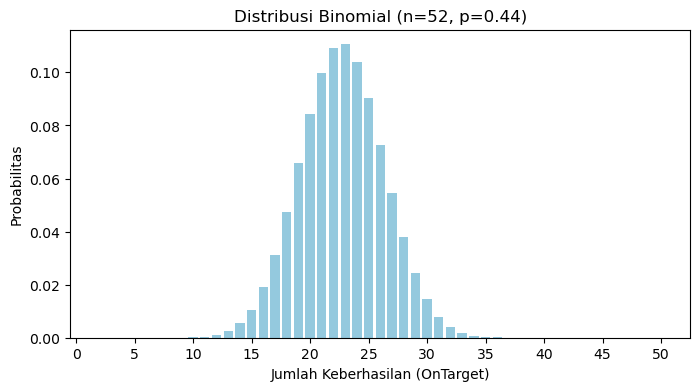

📊 Rata-rata (mean) sukses: 22.73
📉 Variansi: 12.79
🎯 Peluang sukses per percobaan: 0.44


In [76]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom

# n pakai rata-rata Shots biar realistis
n = int(df['Shots'].mean())  # bukan max lagi
p = df['OnTarget'].sum() / df['Shots'].sum()

# Simulasi distribusi binomial
x = np.arange(0, n + 1)
binom_probs = binom.pmf(x, n, p)

# Plot
plt.figure(figsize=(8,4))
sns.barplot(x=x, y=binom_probs, color='skyblue')
plt.title(f'Distribusi Binomial (n={n}, p={p:.2f})')
plt.xlabel('Jumlah Keberhasilan (OnTarget)')
plt.ylabel('Probabilitas')
plt.xticks(range(0, n + 1, max(1, n // 10)))  # supaya label tidak bertumpuk
plt.show()

print(f"📊 Rata-rata (mean) sukses: {n*p:.2f}")
print(f"📉 Variansi: {n*p*(1-p):.2f}")
print(f"🎯 Peluang sukses per percobaan: {p:.2f}")

Kapan Disebut Distribusi Binomial

Setiap percobaan hanya dua hasil (sukses/gagal) → Ciri utama binomial       
Jumlah percobaan (n) tetap → Semua observasi punya kesempatan sama          
Probabilitas sukses (p) konstan di setiap percobaan → Tidak berubah antar kejadian          
Data berbentuk diskrit (integer) → Hasil berupa hitungan, bukan pecahan         
Bentuk condong tergantung besar p → p=0.5 simetris, p<0.5 condong kanan, p>0.5 condong kiri         

### CDF dan ECDF

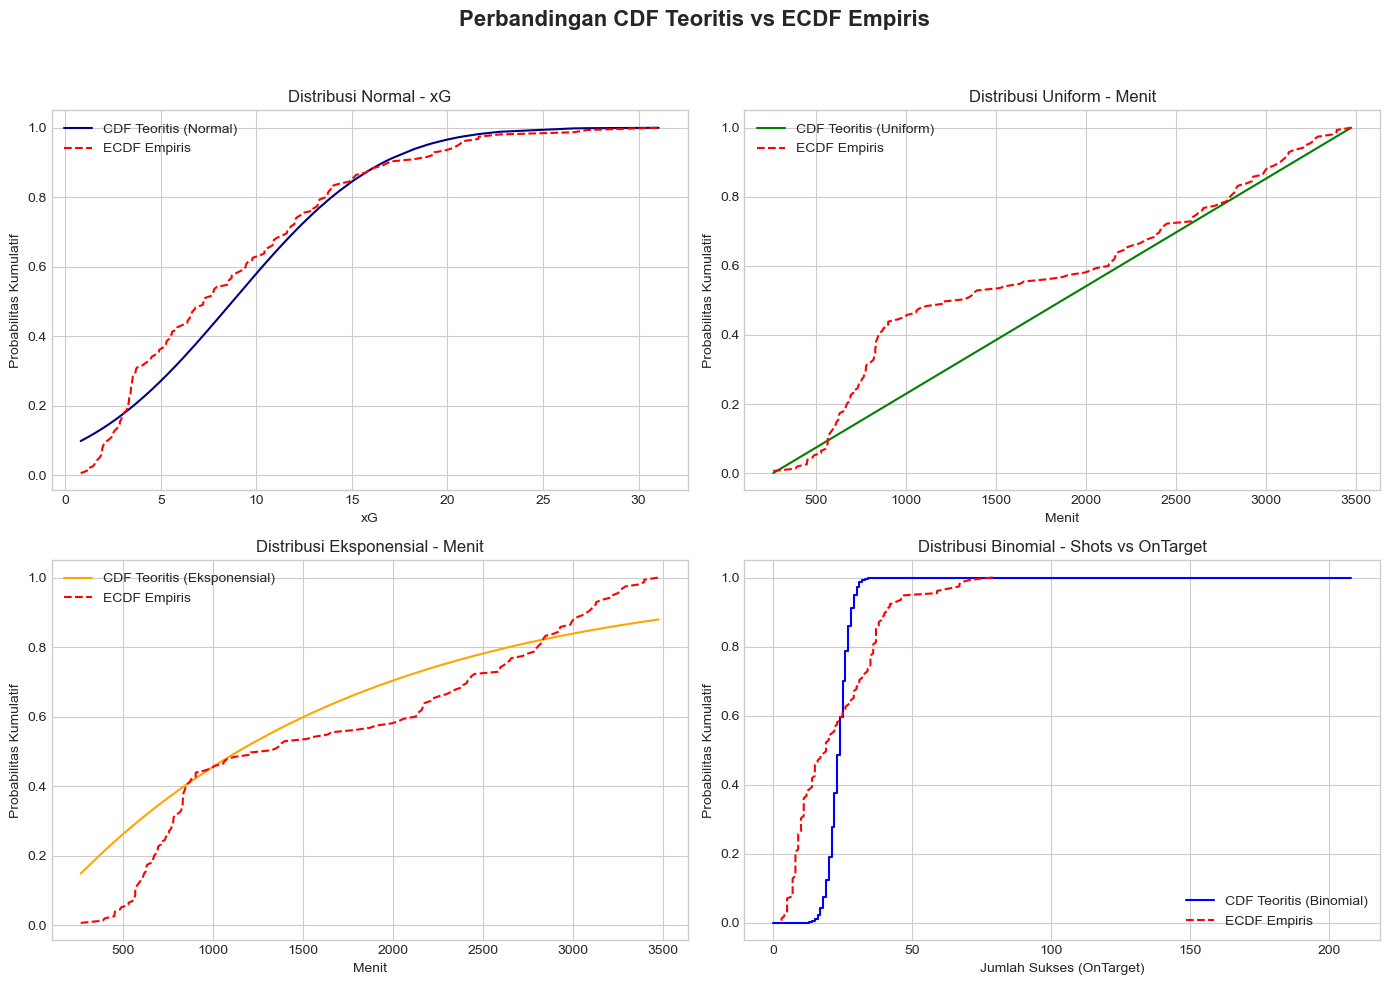

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform, expon, binom

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Perbandingan CDF Teoritis vs ECDF Empiris", fontsize=16, fontweight='bold')

# ------------------------------
# FUNGSI ECDF (Empirical CDF)
# ------------------------------
def ecdf(data):
    """Hitung Empirical CDF"""
    x = np.sort(data)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

# ==========================================
# 1️⃣ Distribusi NORMAL – kolom xG
# ==========================================
x = df["xG"]
mu, sigma = x.mean(), x.std()

# CDF teoritis
x_sorted = np.sort(x)
cdf_theory = norm.cdf(x_sorted, loc=mu, scale=sigma)

# ECDF empiris
x_ecdf, y_ecdf = ecdf(x)

# Plot
axes[0, 0].plot(x_sorted, cdf_theory, label="CDF Teoritis (Normal)", color="navy")
axes[0, 0].plot(x_ecdf, y_ecdf, label="ECDF Empiris", color="red", linestyle="--")
axes[0, 0].set_title("Distribusi Normal - xG")
axes[0, 0].legend()
axes[0, 0].set_xlabel("xG")
axes[0, 0].set_ylabel("Probabilitas Kumulatif")

# ==========================================
# 2️⃣ Distribusi UNIFORM – kolom Menit
# ==========================================
x = df["Menit"]
a, b = x.min(), x.max()

# CDF teoritis
x_sorted = np.sort(x)
cdf_theory = uniform.cdf(x_sorted, loc=a, scale=b - a)

# ECDF empiris
x_ecdf, y_ecdf = ecdf(x)

axes[0, 1].plot(x_sorted, cdf_theory, label="CDF Teoritis (Uniform)", color="green")
axes[0, 1].plot(x_ecdf, y_ecdf, label="ECDF Empiris", color="red", linestyle="--")
axes[0, 1].set_title("Distribusi Uniform - Menit")
axes[0, 1].legend()
axes[0, 1].set_xlabel("Menit")
axes[0, 1].set_ylabel("Probabilitas Kumulatif")

# ==========================================
# 3️⃣ Distribusi EKSPONENSIAL – kolom Menit
# ==========================================
x = df["Menit"]
lambda_ = 1 / x.mean()

# CDF teoritis
x_sorted = np.sort(x)
cdf_theory = expon.cdf(x_sorted, scale=1/lambda_)

# ECDF empiris
x_ecdf, y_ecdf = ecdf(x)

axes[1, 0].plot(x_sorted, cdf_theory, label="CDF Teoritis (Eksponensial)", color="orange")
axes[1, 0].plot(x_ecdf, y_ecdf, label="ECDF Empiris", color="red", linestyle="--")
axes[1, 0].set_title("Distribusi Eksponensial - Menit")
axes[1, 0].legend()
axes[1, 0].set_xlabel("Menit")
axes[1, 0].set_ylabel("Probabilitas Kumulatif")

# ==========================================
# 4️⃣ Distribusi BINOMIAL – Shots & OnTarget
# ==========================================
n = df["Shots"]
k = df["OnTarget"]
p = (k / n).mean()

# CDF teoritis
x_vals = np.arange(0, n.max() + 1)
cdf_theory = binom.cdf(x_vals, n=int(n.mean()), p=p)

# ECDF empiris
x_ecdf, y_ecdf = ecdf(k)

axes[1, 1].step(x_vals, cdf_theory, label="CDF Teoritis (Binomial)", color="blue", where="post")
axes[1, 1].plot(x_ecdf, y_ecdf, label="ECDF Empiris", color="red", linestyle="--")
axes[1, 1].set_title("Distribusi Binomial - Shots vs OnTarget")
axes[1, 1].legend()
axes[1, 1].set_xlabel("Jumlah Sukses (OnTarget)")
axes[1, 1].set_ylabel("Probabilitas Kumulatif")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Distribusi Normal – Kolom xG

- Garis biru (CDF teoritis) menunjukkan sebaran ideal kalau xG memang normal.   
- Garis merah (ECDF) menggambarkan sebaran data nyata.  
- Jika kedua garis hampir menempel → data xG mengikuti pola normal.
- Jika ECDF lebih miring atau menyimpang (lebih cepat naik di ujung kiri/kanan) → data agak skewed (condong ke kiri atau kanan).

Distribusi Uniform – Kolom Menit

- Garis hijau harus hampir lurus diagonal kalau datanya benar-benar seragam (uniform).      
ECDF merah:
- Kalau mengikuti garis → nilai Menit tersebar merata di seluruh rentang.
- Kalau ECDF naik tajam di titik tertentu → berarti ada rentang menit tertentu yang lebih sering muncul.

Distribusi Eksponensial – Kolom Menit
- Digunakan kalau data menggambarkan waktu antar kejadian.
- Jika ECDF mengikuti kurva eksponensial (naik cepat di awal, lalu melandai), berarti data cocok.
- Kalau ECDF jauh lebih lambat → kejadian tidak mengikuti pola acak eksponensial (misal ada pola waktu tertentu).

Distribusi Binomial – Kolom Shots & OnTarget

- Menunjukkan peluang sukses (OnTarget) dari sejumlah percobaan (Shots).
- Kalau ECDF mendekati CDF binomial → distribusi jumlah tembakan yang tepat sasaran cocok dengan model probabilitas biner.
- Kalau ECDF jauh berbeda → bisa jadi peluang sukses bervariasi antar observasi (tidak konstan).

### Subset kolom yang dianalisis

In [ ]:
# Import pustaka yang dibutuhkan
import pandas as pd

# Melakukan subset kolom yang relevan untuk analisis performa pemain
subset_df = df[[
    "Negara", "Liga", "Nama Pemain",
    "Goals", "xG", "Shots", "OnTarget", "value"
]]

# Menampilkan data
subset_df

### Groupby bertingkat & agregasi (min/max/mean/sum/custom)

In [ ]:
# Melakukan pengelompokan bertingkat berdasarkan Negara dan Liga
# dan melakukan agregasi pada beberapa kolom numerik

grouped_df = df.groupby(["Negara", "Liga"]).agg({
    "Goals": ["sum", "mean", "max"],
    "Shots": ["sum", "mean"],
    "OnTarget": ["mean"],
    "value": ["mean", "max"]
}).reset_index()

# Menampilkan hasil
grouped_df

### Transform per kelompok (mis. z-score per wilayah/segmen)

In [ ]:
# Menghitung z-score jumlah gol per liga
# z-score menunjukkan seberapa jauh nilai seorang pemain dari rata-rata liga

df["Zscore_Goals_Liga"] = df.groupby("Liga")["Goals"].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Menampilkan 5 data teratas setelah penambahan kolom z-score
df[["Liga", "Nama Pemain", "Goals", "Zscore_Goals_Liga"]]

### Pivot table & crosstab (tabulasi silang kategori × waktu/wilayah)

In [ ]:
# Membuat pivot table untuk melihat total gol berdasarkan Negara dan Liga
pivot_goals = pd.pivot_table(
    df,
    values="Goals",
    index="Negara",
    columns="Liga",
    aggfunc="sum",
    fill_value=0
)

# Membuat crosstab untuk melihat jumlah pemain berdasarkan Negara dan kategori Menit_Bin
crosstab_players = pd.crosstab(
    index=df["Negara"],
    columns=df["Menit_Bin"]
)

# Menampilkan hasil pivot table dan crosstab
print("Pivot Table - Total Goals per Negara dan Liga:")
display(pivot_goals.head())

print("\nCrosstab - Jumlah Pemain per Negara berdasarkan Kategori Menit_Bin:")
display(crosstab_players.head())

## Story Teller

In [78]:
# import pandas as pd
# import json, html, sys
# import numpy as np
# from pathlib import Path

# INPUT = "merged_df.csv"
# OUTPUT = "football_dashboard.html"

# if not Path(INPUT).exists():
#     print(f"ERROR: '{INPUT}' not found in folder {Path.cwd()}")
#     sys.exit(1)

# df = pd.read_csv(INPUT)
# df.columns = df.columns.str.strip()

# cols = df.columns.tolist()

# numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# for c in df.columns:
#     if c not in numeric_cols:
#         coerced = pd.to_numeric(df[c], errors="coerce")
#         if coerced.notna().sum() / max(1, len(coerced)) > 0.5:
#             numeric_cols.append(c)

# cols_lower = [c.lower() for c in df.columns]
# def find_col(cands):
#     for s in cands:
#         if s.lower() in cols_lower:
#             return df.columns[cols_lower.index(s.lower())]
#     return None

# COL_LEAGUE = find_col(["league","liga","League"])
# COL_PLAYER = find_col(["player names","player_name","player","name"])
# COL_MARKET = find_col(["market value","market_value","value (€)","value","marketvalue","market value (€)"])
# COL_GOALS = find_col(["goals","goal","goals_scored"])
# COL_SHOTS = find_col(["shots","shots per game","total shots","shots_per_game"])

# records = df.where(pd.notnull(df), None).to_dict(orient="records")
# DATA_JSON = json.dumps(records, ensure_ascii=False)
# ALL_COLS_JSON = json.dumps(cols, ensure_ascii=False)
# NUMERIC_COLS_JSON = json.dumps(numeric_cols, ensure_ascii=False)
# LEAGUES = sorted(list(pd.unique(df[COL_LEAGUE].dropna()))) if COL_LEAGUE else []
# LEAGUES_JSON = json.dumps(LEAGUES, ensure_ascii=False)

# def js_str(x):
#     return json.dumps(x, ensure_ascii=False) if x is not None else "null"

# COL_PLAYER_JS = js_str(COL_PLAYER)
# COL_MARKET_JS = js_str(COL_MARKET)
# COL_GOALS_JS = js_str(COL_GOALS)
# COL_SHOTS_JS = js_str(COL_SHOTS)
# COL_LEAGUE_JS = js_str(COL_LEAGUE)

# html_template = """
# <!doctype html>
# <html lang="id">
# <head>
# <meta charset="utf-8" />
# <meta name="viewport" content="width=device-width,initial-scale=1" />
# <title>Football Player Performance Dashboard</title>
# <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
# <style>
# :root{--bg:#f7f9fc;--card:#fff;--accent:#0d6efd;--muted:#6c757d}
# body{font-family:Inter,system-ui,-apple-system,"Segoe UI",Roboto,Arial;background:var(--bg);margin:18px;color:#111}
# .container{max-width:1200px;margin:0 auto}
# header{text-align:center;margin-bottom:12px}
# h1{margin:6px 0;color:var(--accent)}
# .card{background:var(--card);border-radius:10px;padding:12px;box-shadow:0 6px 20px rgba(20,30,50,0.06);margin-bottom:12px}
# .controls{display:flex;flex-wrap:wrap;gap:10px;align-items:center}
# select,button{padding:8px 10px;border-radius:8px;border:1px solid #e6eef8;background:white;font-size:0.95rem}
# .kpi-table{width:100%;border-collapse:collapse;margin-top:8px}
# .kpi-table th,.kpi-table td{padding:8px 10px;border-bottom:1px solid #f0f3f8;text-align:center}
# .grid{display:grid;grid-template-columns:1fr 1fr;gap:12px}
# .plot{width:100%;height:480px}
# .small-note{color:var(--muted);font-size:0.95rem;margin-top:6px}
# .interp{white-space:pre-wrap;background:#f0f8ff;padding:12px;border-radius:8px;border:1px solid #e6f2ff;margin-top:8px}
# @media(max-width:1000px){.grid{grid-template-columns:1fr}.plot{height:420px}}
# </style>
# </head>
# <body>
# <div class="container">
#   <header>
#     <h1>⚽ Football Player Performance Dashboard</h1>
#     <div class="card">
#       <p style="margin:0;">
#         Dashboard interaktif ini membantu mengeksplorasi hubungan antara atribut performa pemain dan nilai pasar (market value). Pilih liga dan variabel untuk menyesuaikan analisis.
#       </p>
#     </div>
#   </header>

#   <div class="card">
#     <div class="controls">
#       <label><strong>Filter Liga</strong></label>
#       <select id="leagueSelect"><option>Semua Liga</option></select>

#       <label><strong>Variabel X</strong></label>
#       <select id="xSelect"></select>

#       <label><strong>Variabel Y</strong></label>
#       <select id="ySelect"></select>

#       <button id="applyBtn">Terapkan</button>
#       <button id="resetBtn">Reset</button>
#     </div>

#     <div id="sameVarDisclaimer" class="small-note" style="margin-top:8px; display:none; color:#b00;"></div>

#     <div id="exec" style="margin-top:12px;">
#       <h3>📋 Executive Summary</h3>
#       <div id="execText" class="small-note"></div>
#     </div>
#   </div>

#   <div class="card">
#     <h4>📊 Ringkasan KPI</h4>
#     <div id="kpiArea"></div>
#   </div>

#   <div class="card">
#     <h4>⚙️ Distribusi Pemain Berdasarkan Liga</h4>
#     <div id="pie" class="plot"></div>
#     <div id="pieInterp" class="interp"></div>
#   </div>

#   <div class="grid">
#     <div class="card">
#       <h4>📈 Scatter Plot</h4>
#       <div id="scatter" class="plot"></div>
#       <div id="scatterInterp" class="interp"></div>
#     </div>

#     <div class="card">
#       <h4>🏆 Bar Chart (Top 10 Market Value)</h4>
#       <div id="bar" class="plot"></div>
#       <div id="barInterp" class="interp"></div>
#     </div>

#     <div class="card">
#       <h4>🟣 Box Plot (Distribusi Y)</h4>
#       <div id="box" class="plot"></div>
#       <div id="boxInterp" class="interp"></div>
#     </div>

#     <div class="card" style="grid-column: span 2;">
#       <h4>🔴 Heatmap Korelasi (Numerik)</h4>
#       <div id="heat" class="plot"></div>
#       <div id="heatInterp" class="interp"></div>
#     </div>
#   </div>

#   <div class="card">
#     <h4>📑 Analisis Temuan Dinamis</h4>
#     <div id="analysisText" class="interp"></div>
#   </div>

#   <footer style="text-align:center;color:#666;margin-top:10px;">Generated from <strong>{INPUT_CSV}</strong></footer>
# </div>

# <script>
# const DATA = __DATA__;
# const ALL_COLS = __ALL_COLS__;
# const NUMERIC_COLS = __NUMERIC_COLS__;
# const LEAGUES = __LEAGUES__;
# const COL_PLAYER = __COL_PLAYER__;
# const COL_MARKET = __COL_MARKET__;
# const COL_GOALS = __COL_GOALS__;
# const COL_SHOTS = __COL_SHOTS__;
# const COL_LEAGUE = __COL_LEAGUE__;

# function safeNum(v){ const n=Number(v); return (v===null||v===undefined||v==="")?null:(isNaN(n)?null:n); }
# function pearson(xs, ys){
#   if(!xs||!ys||xs.length!==ys.length||xs.length<2) return null;
#   const n=xs.length; const mx=xs.reduce((a,b)=>a+b,0)/n; const my=ys.reduce((a,b)=>a+b,0)/n;
#   let num=0,sx=0,sy=0;
#   for(let i=0;i<n;i++){ num+=(xs[i]-mx)*(ys[i]-my); sx+=(xs[i]-mx)**2; sy+=(ys[i]-my)**2; }
#   const den=Math.sqrt(sx*sy); if(den===0) return 0; return num/den;
# }

# const leagueSel = document.getElementById('leagueSelect');
# const xSel = document.getElementById('xSelect');
# const ySel = document.getElementById('ySelect');
# const applyBtn = document.getElementById('applyBtn');
# const resetBtn = document.getElementById('resetBtn');
# const sameVarDisclaimer = document.getElementById('sameVarDisclaimer');

# function populateControls(){
#   leagueSel.innerHTML = "<option>Semua Liga</option>";
#   LEAGUES.forEach(l => { const o=document.createElement('option'); o.value=o.text=l; leagueSel.appendChild(o); });
#   xSel.innerHTML = ""; ySel.innerHTML = "";
#   ALL_COLS.forEach(c => { const ox=document.createElement('option'); ox.value=ox.text=c; xSel.appendChild(ox); const oy=document.createElement('option'); oy.value=oy.text=c; ySel.appendChild(oy); });
#   if(ALL_COLS.includes(COL_MARKET)) xSel.value = COL_MARKET;
#   if(ALL_COLS.includes(COL_GOALS)) ySel.value = COL_GOALS;
# }
# populateControls();

# function getFiltered(){
#   const league = leagueSel.value;
#   if(league && league!=='Semua Liga' && COL_LEAGUE !== null) return DATA.filter(r=>r[COL_LEAGUE]===league);
#   return [...DATA];
# }

# function renderExec(filtered){
#   const el = document.getElementById('execText');
#   const totalAll = DATA.length;
#   const leagueText = leagueSel.value==='Semua Liga' ? 'seluruh liga' : leagueSel.value;
#   el.innerHTML = `Dashboard ini menampilkan eksplorasi data terhadap <b>${totalAll}</b> pemain sepak bola profesional. Saat ini menampilkan <b>${filtered.length}</b> pemain dari <b>${leagueText}</b>.<br><br>
# Analisis memungkinkan pengguna melihat keterkaitan antara atribut performa (mis. goals, shots, age) dengan market value. Visualisasi: scatter plot, bar chart (top 10), box plot, heatmap (korelasi), dan pie chart (distribusi liga). Gunakan filter dan pilih variabel X & Y untuk menyesuaikan analisis.`;
# }

# function renderKPI(filtered){
#   const area = document.getElementById('kpiArea');
#   let avgMarket='N/A', avgGoals='N/A', avgShots='N/A';
#   if(COL_MARKET!==null){
#     const arr = filtered.map(r=>safeNum(r[COL_MARKET])).filter(v=>v!==null);
#     if(arr.length) avgMarket = Math.round((arr.reduce((a,b)=>a+b,0)/arr.length)*100)/100;
#   }
#   if(COL_GOALS!==null){
#     const arr = filtered.map(r=>safeNum(r[COL_GOALS])).filter(v=>v!==null);
#     if(arr.length) avgGoals = (arr.reduce((a,b)=>a+b,0)/arr.length).toFixed(2);
#   }
#   if(COL_SHOTS!==null){
#     const arr = filtered.map(r=>safeNum(r[COL_SHOTS])).filter(v=>v!==null);
#     if(arr.length) avgShots = (arr.reduce((a,b)=>a+b,0)/arr.length).toFixed(2);
#   }
#   area.innerHTML = `<table class="kpi-table">
#     <tr><th>Indikator</th><th>Nilai</th></tr>
#     <tr><td>Rata-rata Market Value (€)</td><td>${avgMarket}</td></tr>
#     <tr><td>Rata-rata Goals</td><td>${avgGoals}</td></tr>
#     <tr><td>Rata-rata Shots</td><td>${avgShots}</td></tr>
#     <tr><td>Total Pemain</td><td>${filtered.length}</td></tr>
#   </table>`;
# }

# function renderPie(filtered){
#   const counts = {};
#   filtered.forEach(r=>{ const k = COL_LEAGUE ? (r[COL_LEAGUE]||"Unknown") : "Unknown"; counts[k]=(counts[k]||0)+1; });
#   const labels = Object.keys(counts); const values = labels.map(l=>counts[l]);
#   Plotly.newPlot('pie', [{labels:labels, values:values, type:'pie', textinfo:'label+percent'}], {height:480, title:'Distribusi Pemain per Liga'}, {responsive:true});
#   document.getElementById('pieInterp').innerText = `Grafik pie ini memperlihatkan bahwa distribusi pemain antar liga ${labels.length? 'memiliki proporsi: '+labels.map((l,i)=> l+' ('+values[i]+')').join(', '):'tidak tersedia'}. Jika satu liga mendominasi, dataset lebih fokus pada liga tersebut; sebaran seimbang menandakan data lebih representatif antar liga.`;
# }

# function renderBar(filtered){
#   const area = document.getElementById('bar');
#   if(COL_MARKET===null || COL_PLAYER===null){ area.innerHTML = "<div style='padding:12px;color:#b00;'>Kolom nama pemain atau market value tidak ditemukan.</div>"; document.getElementById('barInterp').innerText=''; return; }
#   const map = {};
#   filtered.forEach(r=>{ const name = r[COL_PLAYER]||"Unknown"; const val = safeNum(r[COL_MARKET]); if(val!==null){ if(!map[name]||val>map[name]) map[name]=val;} });
#   const items = Object.keys(map).map(k=>({name:k,val:map[k]})).sort((a,b)=>b.val-a.val).slice(0,10);
#   if(items.length===0){ area.innerHTML = "<div style='padding:12px;color:#b00;'>Tidak ada data market value untuk Top 10.</div>"; document.getElementById('barInterp').innerText=''; return; }
#   const trace = { x: items.map(i=>i.name).reverse(), y: items.map(i=>i.val).reverse(), type:'bar', text: items.map(i=>(i.val/1e6).toFixed(1)+'M'), textposition:'outside', marker:{color: items.map((_,i)=>['#2b8cbe','#66c2a5','#fc8d62','#8da0cb','#e78ac3'][i%5])} };
#   Plotly.newPlot('bar', [trace], {height:480, title:'Top 10 Pemain Berdasarkan Market Value'}, {responsive:true});
#   document.getElementById('barInterp').innerText = `Grafik batang ini memperlihatkan bahwa pemain dengan market value tertinggi cenderung terfokus pada beberapa nama; perbandingan ini membantu mengidentifikasi gap nilai antar pemain bintang dan pemain lainnya.`;
# }

# function renderScatter(filtered){
#   const x = xSel.value, y = ySel.value; const interp = document.getElementById('scatterInterp');
#   if(x===y){ sameVarDisclaimer.style.display='block'; sameVarDisclaimer.innerText = `Jika kamu memilih variabel yang sama (misalnya: ${x}), scatter plot akan menjadi garis lurus karena kedua sumbu identik.`; }
#   else { sameVarDisclaimer.style.display='none'; }
#   if(!(NUMERIC_COLS.includes(x) && NUMERIC_COLS.includes(y))){ document.getElementById('scatter').innerHTML = "<div style='padding:12px;color:#b00;'>Scatter plot hanya dapat dibuat jika kedua variabel numerik.</div>"; interp.innerText=""; return; }
#   const groups = {}; filtered.forEach(r=>{ const lg = COL_LEAGUE? (r[COL_LEAGUE]||"Unknown") : "Unknown"; const xv=safeNum(r[x]); const yv=safeNum(r[y]); if(xv!==null&&yv!==null){ if(!groups[lg]) groups[lg]=[]; groups[lg].push({x:xv,y:yv,text:r[COL_PLAYER]||""}); } });
#   const traces=[]; Object.entries(groups).forEach(([lg,pts],idx)=>{ traces.push({ x: pts.map(p=>p.x), y: pts.map(p=>p.y), mode:'markers', type:'scatter', name: lg, text: pts.map(p=>p.text), marker:{size:8} }); });
#   Plotly.newPlot('scatter', traces, {height:480, title:`Hubungan antara ${x} dan ${y}`, xaxis:{title:x}, yaxis:{title:y}}, {responsive:true});
#   const xs=[], ys=[]; filtered.forEach(r=>{ const xv=safeNum(r[x]); const yv=safeNum(r[y]); if(xv!==null&&yv!==null){ xs.push(xv); ys.push(yv);} });
#   if(xs.length>1){ const c = pearson(xs, ys); interp.innerText = `Nilai korelasi Pearson antara ${x} dan ${y} adalah ${c.toFixed(2)}.`; }
#   else { interp.innerText = "Tidak cukup data numerik untuk menghitung korelasi."; }
#   // paragraph interpretation (dynamic)
#   let para = `Grafik scatter ini memperlihatkan bahwa hubungan antara ${x} dan ${y} `;
#   if(xs.length>1){
#     const c = pearson(xs, ys);
#     if(Math.abs(c) >= 0.7) para += `termasuk kuat (korelasi Pearson ${c.toFixed(2)}). Secara umum, pola titik menunjukkan hubungan yang konsisten antara kedua variabel.`;
#     else if(Math.abs(c) >= 0.3) para += `termasuk sedang (korelasi Pearson ${c.toFixed(2)}). Ada kecenderungan pola yang dapat dijelaskan tetapi juga variasi.`;
#     else para += `termasuk lemah atau tidak signifikan (korelasi Pearson ${c.toFixed(2)}); titik-titik lebih tersebar, menandakan sedikit hubungan linier antara keduanya.`;
#   } else {
#     para += "tidak cukup data untuk analisis detail.";
#   }
#   interp.innerText += "\\n\\n" + para;
# }

# function renderBox(filtered){
#   const y = ySel.value; const area = document.getElementById('box'); const interp = document.getElementById('boxInterp');
#   if(!NUMERIC_COLS.includes(y)){ area.innerHTML = "<div style='padding:12px;color:#b00;'>Boxplot hanya dapat dibuat untuk variabel numerik (Y).</div>"; interp.innerText=""; return; }
#   const arr = filtered.map(r=>safeNum(r[y])).filter(v=>v!==null);
#   if(arr.length===0){ area.innerHTML = "<div style='padding:12px;color:#b00;'>Tidak ada data numerik untuk boxplot.</div>"; interp.innerText=""; return; }
#   Plotly.newPlot('box', [{y:arr,type:'box',boxpoints:'outliers',marker:{color:'#8a2be2'}}], {height:480, title:`Distribusi ${y}`}, {responsive:true});
#   const q1 = quantile(arr,0.25), q3 = quantile(arr,0.75), med = quantile(arr,0.5);
#   interp.innerText = `Grafik boxplot ini memperlihatkan bahwa distribusi ${y} memiliki median ${med.toFixed(2)}, rentang interkuartil (Q1–Q3) dari ${q1.toFixed(2)} sampai ${q3.toFixed(2)}. Titik di luar rentang menandakan outlier yang mungkin merupakan kasus ekstrem atau data yang perlu ditinjau.`;
# }

# function renderHeat(filtered){
#   if(NUMERIC_COLS.length===0){ document.getElementById('heat').innerHTML="<div style='padding:12px;color:#b00;'>Tidak ada kolom numerik untuk heatmap.</div>"; document.getElementById('heatInterp').innerText=""; return; }
#   const cols = NUMERIC_COLS.slice(); const n = cols.length; const z = Array.from({length:n}, ()=>Array(n).fill(0));
#   for(let i=0;i<n;i++){ for(let j=0;j<n;j++){
#     const pairedX=[], pairedY=[];
#     filtered.forEach(r=>{ const a=safeNum(r[cols[i]]); const b=safeNum(r[cols[j]]); if(a!==null&&b!==null){ pairedX.push(a); pairedY.push(b); } });
#     z[i][j] = pairedX.length>1 ? pearson(pairedX, pairedY) : 0;
#   } }
#   const annotations=[]; for(let i=0;i<n;i++){ for(let j=0;j<n;j++){ annotations.push({ x:cols[j], y:cols[i], text: z[i][j].toFixed(2), showarrow:false, font:{color: Math.abs(z[i][j])>0.5? 'white':'black', size:11} }); } }
#   const data=[{ z:z.map(row=>row.map(v=>Number(v.toFixed(2)))), x:cols, y:cols, type:'heatmap', colorscale:'RdBu', zmin:-1, zmax:1 }];
#   const layout={height:520, title:'Korelasi antar Variabel Numerik', annotations:annotations, margin:{l:140, r:40, t:80, b:140}};
#   Plotly.newPlot('heat', data, layout, {responsive:true});
#   document.getElementById('heatInterp').innerText = "Grafik heatmap ini memperlihatkan angka korelasi Pearson antar kolom numerik. Nilai mendekati 1 menunjukkan korelasi positif kuat; mendekati -1 menunjukkan korelasi negatif kuat; nilai dekat 0 menunjukkan tidak ada korelasi linear yang jelas.";
# }

# function renderAnalysis(filtered){
#   const x = xSel.value, y = ySel.value; const el = document.getElementById('analysisText');
#   let text = "";
#   if(x===y){
#     text += `Catatan: Kamu memilih variabel yang sama (${x}). Scatter plot akan menjadi garis diagonal — ini tidak memberi insight korelasi karena X selalu sama dengan Y.`;
#   } else if(NUMERIC_COLS.includes(x) && NUMERIC_COLS.includes(y)){
#     const xs=[], ys=[]; filtered.forEach(r=>{ const a=safeNum(r[x]); const b=safeNum(r[y]); if(a!==null&&b!==null){ xs.push(a); ys.push(b); } });
#     if(xs.length>1){
#       const c = pearson(xs, ys); const arah = c>0? 'searah (positif)' : (c<0? 'berlawanan arah (negatif)': 'tidak signifikan');
#       text += `Berdasarkan analisis korelasi, terdapat nilai Pearson ${c.toFixed(2)} antara ${x} dan ${y}, yang menunjukkan hubungan ${arah}. Korelasi ini membantu menjelaskan seberapa besar perubahan pada ${x} berasosiasi dengan perubahan pada ${y}.`;
#     } else text += "Tidak cukup data numerik untuk analisis korelasi yang kuat.";
#   } else {
#     text += `Variabel ${x} dan ${y} tidak keduanya numerik, sehingga analisis korelasi numerik tidak tersedia. Gunakan kombinasi visual kategorikal atau distribusi untuk memahami pola.`;
#   }
#   el.innerText = text;
# }

# function quantile(arr,q){
#   const s = arr.slice().sort((a,b)=>a-b); const pos = (s.length-1)*q; const base = Math.floor(pos); const rest = pos-base;
#   if(s[base+1]!==undefined) return s[base] + rest*(s[base+1]-s[base]);
#   return s[base];
# }

# function renderAll(){
#   const filtered = getFiltered();
#   renderExec(filtered);
#   renderKPI(filtered);
#   renderPie(filtered);
#   renderBar(filtered);
#   renderScatter(filtered);
#   renderBox(filtered);
#   renderHeat(filtered);
#   renderAnalysis(filtered);
# }

# applyBtn.addEventListener('click', renderAll);
# leagueSel.addEventListener('change', renderAll);
# xSel.addEventListener('change', renderAll);
# ySel.addEventListener('change', renderAll);
# resetBtn.addEventListener('click', ()=>{ populateControls(); renderAll(); });

# function populateControls(){ leagueSel.innerHTML="<option>Semua Liga</option>"; LEAGUES.forEach(l=>{ const o=document.createElement('option'); o.value=o.text=l; leagueSel.appendChild(o); });
#   xSel.innerHTML=""; ySel.innerHTML=""; ALL_COLS.forEach(c=>{ const ox=document.createElement('option'); ox.value=ox.text=c; xSel.appendChild(ox); const oy=document.createElement('option'); oy.value=oy.text=c; ySel.appendChild(oy); });
#   if(ALL_COLS.includes(COL_MARKET)) xSel.value = COL_MARKET;
#   if(ALL_COLS.includes(COL_GOALS)) ySel.value = COL_GOALS;
# }
# populateControls();
# renderAll();
# </script>
# </body>
# </html>
# """

# filled = html_template.replace("__DATA__", DATA_JSON)\
#                       .replace("__ALL_COLS__", ALL_COLS_JSON)\
#                       .replace("__NUMERIC_COLS__", NUMERIC_COLS_JSON)\
#                       .replace("__LEAGUES__", LEAGUES_JSON)\
#                       .replace("__COL_PLAYER__", COL_PLAYER_JS)\
#                       .replace("__COL_MARKET__", COL_MARKET_JS)\
#                       .replace("__COL_GOALS__", COL_GOALS_JS)\
#                       .replace("__COL_SHOTS__", COL_SHOTS_JS)\
#                       .replace("__COL_LEAGUE__", COL_LEAGUE_JS)\
#                       .replace("{INPUT_CSV}", html.escape(INPUT))

# with open(OUTPUT, "w", encoding="utf-8") as f:
#     f.write(filled)

# print(f"Selesai — buka '{OUTPUT}' di browser (double-click).")

Kode dashboard ini tidak dapat dijalankan di Google Colab karena menggunakan proses pembuatan file HTML statis dan membutuhkan akses langsung ke sistem file lokal untuk membaca serta menulis data. Selain itu, Colab tidak mendukung tampilan interaktif langsung dari file HTML secara dinamis menggunakan JavaScript. Oleh karena itu, kode ini harus dijalankan di Visual Studio Code (VSCode) atau lingkungan lokal lainnya yang mendukung eksekusi file Python secara penuh. Setelah dijalankan, kode akan menghasilkan file football_dashboard.html yang dapat dibuka langsung di browser untuk melihat dashboard interaktif.